Research question 

To what extent are municipalities able to achieve “green growth” (or post-growth?) in British Columbia, as measured by a decoupling of growth in wellbeing from the growth in transportation and utility GHG emissions? 

What inequities exist in the access of solar energy across B.C.? Do these inequities correlate with lower housing wellbeing index?

Scope 

Timeframe: 2012 – 2021 

Emissions scope: CO2e for utilities of residential and small and medium indistry, on-road transportation

In [16]:
#import libraries
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [17]:
#load the community emissions dataset as csv file
utility_emissions = pd.read_csv('../data/raw/utilities_new.csv')

#replace W's from emissions in wood with 0
utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'] = utility_emissions['EMISSIONS NET IMPORTS (TCO2e)'].replace('W', 0)

# Display the first few rows of the utility emissions dataset
utility_emissions.head()

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2022.0,BC Hydro,11080.0,5909052.0,Abbotsford,1005909.0,ELEC,kWh,Res,538127235.5,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022.0,BC Hydro,11080.0,1005923.0,Alberni-Clayoquot,9000000.0,ELEC,kWh,Res,226116610.6,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022.0,BC Hydro,11080.0,2005923.0,Alberni-Clayoquot Unincorporated Areas,1005923.0,ELEC,kWh,Res,79348847.45,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022.0,BC Hydro,11080.0,5943008.0,Alert Bay,1005943.0,ELEC,kWh,Res,3775260.192,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022.0,BC Hydro,11080.0,5915038.0,Anmore,1005915.0,ELEC,kWh,Res,14323873.26,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# load the transportation emissions dataset as csv file
transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')
transportation_emissions.head()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/1375076493.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  transportation_emissions = pd.read_csv('../data/raw/bc_on_road_transportation_data_at_the_community_level.csv')


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
4,2005951,Bulkley-Nechako Unincorporated Areas,1005951,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.11,1142.083256,573.325795,0.778630,NaN


To add industrial emissions:
1. convert lat and lon of each industry to points that can fall within the area of the municipal boundaries
2. assign the municipality name to each industry in the industries dataset (creating a new column to hold the municipality names in the industry dataset)
3. sum up the emissions of all industries within each municipality area and assign total emissions to that municipality in a new dataset
4. change the naming of municipalities in the shape file to match the naming of the other emissions datasets, so that we can aggregate these emissions

In [19]:
#list of regional districts including typos in datasets
bc_regional_districts = [
    "Alberni-Clayoquot",
    "Bulkley-Nechako",
    "Capital",
    "Cariboo",
    "Central Coast",
    "Central Kootenay",
    "Central Okanagan",
    "Columbia-Shuswap",
    "Comox Valley",
    "Cowichan Valley",
    "East Kootenay",
    "Fraser Valley",
    "Fraser-Fort George",
    "Greater Vancouver",
    "Islands Trust",
    "Kitimat-Stikine",
    "Kootenay Boundary",
    "Metro-Vancouver",
    "Mount Waddington",
    "Nanaimo RD",
    "North Okanagan",
    "Northern Rockies RD",
    "Okanagan-Similkameen",
    "Peace River",
    "qathet",
    "Skeena-Queen Charlotte",
    "Squamish-Lillooet",
    "Stikine",
    "Sitkine",
    "Strathcona",
    "Sunshine Coast",
    "Thompson-Nicola"
]
#list of unincorporated areas
list_of_unincorporated_areas = [
    "Alberni-Clayoquot Unincorporated Areas",
    "Bulkley-Nechako Unincorporated Areas",
    "Capital Unincorporated Areas",
    "Cariboo Unincorporated Areas",
    "Central Coast Unincorporated Areas",
    "Central Kootenay Unincorporated Areas",
    "Central Okanagan Unincorporated Areas",
    "Columbia-Shuswap Unincorporated Areas",
    "Comox Valley Unincorporated Areas",
    "Comox Unincorporated Areas",
    "Cowichan Valley Unincorporated Areas",
    "East Kootenay Unincorporated Areas",
    "Fraser Valley Unincorporated Areas",
    "Fraser-Fort George Unincorporated Areas",
    "Greater Vancouver Unincorporated Areas",
    "Islands Trust Unincorporated Areas",
    "Kitimat-Stikine Unincorporated Areas",
    "Kootenay Boundary Unincorporated Areas",
    "Metro-Vancouver Unincorporated Areas",
    "Mount Waddington Unincorporated Areas",
    "Nanaimo Unincorporated Areas",
    "Northern Rockies Unincorporated Areas", #check if there are variations to this, like Northern Rockies Regional Municipality Unincorporated Areas
    "Skeena-Queen Charlotte Unincorporated Areas",
    "North Okanagan Unincorporated Areas",
    "Okanagan-Similkameen Unincorporated Areas",
    "Peace River Unincorporated Areas",
    "Powell River Unincorporated Areas",
    "qathet Unincorporated Areas",
    "Squamish-Lillooet Unincorporated Areas",
    "Stikine Unincorporated Areas",
    "Sitkine Unincorporated Areas",
    "Sunshine Coast Unincorporated Areas",
    "Strathcona Unincorporated Areas",
    "Thompson-Nicola Unincorporated Areas"
]
province = ["British Columbia"]

Indigenous= ["Sechelt IGD", "Sechelt Ind Gov Dist (Part-Powell River)"]
 
outliers = ["Northern Rockies Regional Municipality","Northern Rockies RD", "Northern Rockies"]

#list of years
years_transportation_co2 = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_buildings_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
years_waste_co2 = [2007, 2010, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

In [20]:
#select municipalities from the utility emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~utility_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
utility_df = utility_emissions[mask]
print(utility_df['ORG_NAME'].unique())
#save the utility_df to a csv file in the data/processed folder
utility_df.to_csv(os.path.join('..','data','processed','municipalities_utility_emissions.csv'), index=False)
utility_df.head()

['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Central Saanich' 'Chase' 'Chetwynd'
 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood' 'Comox'
 'Coquitlam' 'Courtenay' 'Cranbrook' 'Cumberland' 'Dawson Creek' 'Delta'
 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie' 'Fort St. James'
 'Fort St. John' 'Fraser Lake' 'Gibsons' 'Gold River' 'Golden' 'Granisle'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kelowna' 'Kent' 'Kimberley'
 'Kitimat' 'Ladysmith' 'Lake Country' 'Lake Cowichan' 'Langford'
 'Langley City' 'Langley Township' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Mission' 'Nakusp' 'Nanaimo' 'New Denver'
 'New Hazelton' 'North Cowichan' 'North Saanich' 'North Vancouver City'
 'North Vancouver District' 'Nort

,YEAR,SOURCE,Data Source ID,ORG_UNIT,ORG_NAME,ORG_PART,ENERGY_TYPE,ENERGY_UNIT,SUB_SECTOR,CONSUMPTION_TOTAL,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,2022.0,BC Hydro,11080.0,5909052.0,Abbotsford,1005909.0,ELEC,kWh,Res,538127235.5,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022.0,BC Hydro,11080.0,5943008.0,Alert Bay,1005943.0,ELEC,kWh,Res,3775260.192,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022.0,BC Hydro,11080.0,5915038.0,Anmore,1005915.0,ELEC,kWh,Res,14323873.26,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2022.0,BC Hydro,11080.0,5937028.0,Armstrong,1005937.0,ELEC,kWh,Res,21935314.26,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2022.0,BC Hydro,11080.0,5933019.0,Ashcroft,1005933.0,ELEC,kWh,Res,7649213.599,...,2022ELECkWh,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
#select municipalities from the transportation emissions dataset (by excluding regional districts and unincorporated areas)
mask = ~transportation_emissions['ORG_NAME'].isin(list_of_unincorporated_areas + bc_regional_districts + province)
transportation_df = transportation_emissions[mask]

#change names of communities to match the utility_df
# Greater Vancouver -> Metro Vancouver
# Sun Peaks Mountain -> Sun Peaks Mountain Resort
# Sechelt District Municipality -> Sechelt

transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({
    "Greater Vancouver": "Metro Vancouver",
    "Sun Peaks Mountain": "Sun Peaks Mountain Resort",
    "Sechelt District Municipality": "Sechelt",
    "Sechelt Ind Gov Dist (Part-Powell River)": "Sechelt IGD",
    "Sechelt Ind Gov Dist": "Sechelt IGD"
})
transportation_df.to_csv(os.path.join('..','data','processed','municipalities_transportation_emissions.csv'), index=False)
transportation_df.head()
#print(transportation_df['ORG_NAME'].unique())

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/2368270769.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transportation_df['ORG_NAME'] = transportation_df['ORG_NAME'].replace({


,ORG_UNIT,ORG_NAME,ORG_PART,Year,Vehicle Type,Fuel Type,Vehicle Fuel Category,Policy Years Earned,Vehicle Kilometres Travelled,Letres Equivalents,Emissions tCO2e,Unnamed: 11
0,5909052,Abbotsford,1005909,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,1.00,11734.493600,5890.715786,8.010833,NaN
1,5915038,Anmore,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.89,9240.491799,4638.726883,6.308712,NaN
2,5933019,Ashcroft,1005933,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.76,7890.757042,3961.160035,5.388842,NaN
3,5915036,Belcarra,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,0.00,0.000000,0.000000,0.000000,NaN
5,5915025,Burnaby,1005915,2007,Bus,CH,Heavy-Duty Gasoline Vehicles,9.62,112885.828400,56668.685860,77.069859,NaN


In [22]:
# Remove commas from the values, then convert to numeric
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
#remove 'W' from the values and convert to numeric, filling NaN with 0
utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)

#correct norther rockies to northern rockies
utility_df['ORG_NAME'] = utility_df['ORG_NAME'].str.replace('Norther Rockies Regional Municipality', 'Northern Rockies')


# Group by YEAR and ORG_NAME, summing the emissions
total_utility_emissions = utility_df.groupby(
    ['YEAR', 'ORG_NAME'], as_index=False)['EMISSIONS NET IMPORTS (TCO2e)'].sum()


#save to csv file in the data/processed folder
total_utility_emissions.to_csv(os.path.join('..','data','processed','total_utility_emissions.csv'), index=False)
total_utility_emissions.tail()


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/1410149410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = utility_df['EMISSIONS NET IMPORTS (TCO2e)'].astype(str).str.replace(',', '')
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/1410149410.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  utility_df['EMISSIONS NET IMPORTS (TCO2e)'] = pd.to_numeric(utility_df['EMISSIONS NET IMPORTS (TCO2e)'], errors='coerce').fillna(0)
/

,YEAR,ORG_NAME,EMISSIONS NET IMPORTS (TCO2e)
2101,2022.0,West Vancouver,135173.833942
2102,2022.0,Whistler,57678.669702
2103,2022.0,White Rock,42636.687571
2104,2022.0,Williams Lake,86472.003657
2105,2022.0,Zeballos,151.410986


In [23]:
#print all unique org-names in the utilties dataframe
print("Unique organizations in utility emissions:")
print(total_utility_emissions['ORG_NAME'].unique())

Unique organizations in utility emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Mon

In [24]:
print ("\nTotal utility emissions for each community:")
# Display the total utility emissions for each community
print(total_utility_emissions)


Total utility emissions for each community:
        YEAR        ORG_NAME  EMISSIONS NET IMPORTS (TCO2e)
0     2007.0      Abbotsford                  369133.300024
1     2007.0       Alert Bay                     835.510099
2     2007.0          Anmore                    4442.247271
3     2007.0       Armstrong                   11999.055741
4     2007.0        Ashcroft                   14440.813090
...      ...             ...                            ...
2101  2022.0  West Vancouver                  135173.833942
2102  2022.0        Whistler                   57678.669702
2103  2022.0      White Rock                   42636.687571
2104  2022.0   Williams Lake                   86472.003657
2105  2022.0        Zeballos                     151.410986

[2106 rows x 3 columns]


In [77]:
# Create tidy version of utility emissions
tidy_utility = total_utility_emissions.copy()
tidy_utility.rename(columns={'EMISSIONS NET IMPORTS (TCO2e)': 'Value', 'YEAR': 'Year', 'ORG_NAME': 'Municipality_Name'}, inplace=True)
tidy_utility['Metric'] = 'Utility_Emissions'
tidy_utility['Unit'] = 'tCO2e'
tidy_utility = tidy_utility[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]

In [78]:
tidy_utility.head()

,Municipality_Name,Year,Metric,Value,Unit
0,Abbotsford,2007.0,Utility_Emissions,369133.300024,tCO2e
1,Alert Bay,2007.0,Utility_Emissions,835.510099,tCO2e
2,Anmore,2007.0,Utility_Emissions,4442.247271,tCO2e
3,Armstrong,2007.0,Utility_Emissions,11999.055741,tCO2e
4,Ashcroft,2007.0,Utility_Emissions,14440.813090,tCO2e


In [81]:
#for each year and each community, calculate the total emissions for that community by summing the emissions for values in all vehicle fuel categories

# Group by 'YEAR' and 'ORG_NAME' and sum the emissions
total_transportation_emissions = transportation_df.groupby(['Year', 'ORG_NAME'], as_index=False)['Emissions tCO2e'].sum()

#save to csv file in the data/processed folder
total_transportation_emissions.to_csv(os.path.join('..','data','processed','total_transportation_emissions.csv'), index=False)

In [82]:
print("Unique organizations in total_emissions:")
print(total_transportation_emissions['ORG_NAME'].unique())

Unique organizations in total_emissions:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Langley City' 'Langley Township' 'Lantzville'
 'Lillooet' 'Lions Bay' 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie'
 'Maple Ridge' 'Masset' 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission'
 'Montr

In [83]:
print ("\nTotal transportation emissions for each community:")
# Display the total transportation emissions for each community
#total_emissions.head()
print(total_transportation_emissions)


Total transportation emissions for each community:
      Year        ORG_NAME  Emissions tCO2e
0     2007      Abbotsford    466925.103045
1     2007       Alert Bay      1022.397977
2     2007          Anmore      5836.238127
3     2007       Armstrong     21883.647495
4     2007        Ashcroft      7518.235865
...    ...             ...              ...
2571  2022  West Vancouver     87183.024487
2572  2022        Whistler     45378.848302
2573  2022      White Rock     50525.617995
2574  2022   Williams Lake     65210.910339
2575  2022        Zeballos       323.540670

[2576 rows x 3 columns]


In [84]:
# Create tidy version of transportation emissions
tidy_transport = total_transportation_emissions.copy()
tidy_transport.rename(columns={'Emissions tCO2e': 'Value', 'ORG_NAME': 'Municipality_Name'}, inplace=True)
tidy_transport['Metric'] = 'Transportation_Emissions'
tidy_transport['Unit'] = 'tCO2e'
tidy_transport = tidy_transport[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]

In [85]:
tidy_transport.head()

,Municipality_Name,Year,Metric,Value,Unit
0,Abbotsford,2007,Transportation_Emissions,466925.103045,tCO2e
1,Alert Bay,2007,Transportation_Emissions,1022.397977,tCO2e
2,Anmore,2007,Transportation_Emissions,5836.238127,tCO2e
3,Armstrong,2007,Transportation_Emissions,21883.647495,tCO2e
4,Ashcroft,2007,Transportation_Emissions,7518.235865,tCO2e


In [29]:
transportation_emissions_communities_list = set(total_transportation_emissions['ORG_NAME'])
utility_emissions_communities_list = set(total_utility_emissions['ORG_NAME'])
# Find communities that are in transportation emissions but not in utility emissions
missing_communities = transportation_emissions_communities_list - utility_emissions_communities_list
print("\nCommunities in transportation emissions but not in utility emissions:")
print(missing_communities)
# Find communities that are in utility emissions but not in transportation emissions
missing_communities = utility_emissions_communities_list - transportation_emissions_communities_list
print("\nCommunities in utility emissions but not in transportation emissions:")
print(missing_communities)


Communities in transportation emissions but not in utility emissions:
set()

Communities in utility emissions but not in transportation emissions:
{'Northern Rockies Regional Municipality'}


In [30]:
total_transportation_emissions.rename(columns={'Year': 'YEAR'}, inplace=True)


In [31]:
tidy_utility = total_utility_emissions.copy()
tidy_utility['Metric'] = 'Utility_Emissions'
tidy_transport = total_transportation_emissions.copy()
tidy_transport['Metric'] = 'Transport_Emissions'

In [32]:
tidy_utility.head()

,YEAR,ORG_NAME,EMISSIONS NET IMPORTS (TCO2e),Metric
0,2007.0,Abbotsford,369133.300024,Utility_Emissions
1,2007.0,Alert Bay,835.510099,Utility_Emissions
2,2007.0,Anmore,4442.247271,Utility_Emissions
3,2007.0,Armstrong,11999.055741,Utility_Emissions
4,2007.0,Ashcroft,14440.813090,Utility_Emissions


In [39]:
#open CWB_2021 and CWB_2011 from the data folder/raw
# Load the dataset
cwb_2021 = pd.read_csv(os.path.join('..','data','raw','CWB_2021.csv'),encoding='latin-1')
cwb_2016 = pd.read_csv(os.path.join('..','data','raw','CWB_2016.csv'))
cwb_2011 = pd.read_csv(os.path.join('..','data','raw','CWB_2011.csv'),encoding='latin-1')
cwb_2006 = pd.read_csv(os.path.join('..','data','raw','CWB_2006.csv'),encoding='latin-1')
# Display the first few rows of each dataset
print("CWB_2021 dataset:")
print(cwb_2021.head())

print("\n CWB_2016_dataset:")
print(cwb_2016.head())

print("\n CWB_2011_dataset:")
print(cwb_2011.head())

print("\n CWB_2006_dataset:")
print(cwb_2006.head())

CWB_2021 dataset:
   CSD Code 2021             CSD Name 2021  Census Population 2021  \
0        1001101  Division No.  1, Subd. V                    55.0   
1        1001105       Portugal Cove South                    86.0   
2        1001113                 Trepassey                   405.0   
3        1001120               St. Shott's                    55.0   
4        1001124  Division No.  1, Subd. U                  1373.0   

   Income 2021  Education 2021  Housing 2021  Labour Force Activity 2021  \
0          NaN             NaN           NaN                         NaN   
1          NaN             NaN           NaN                         NaN   
2         76.0            48.0          97.0                        70.0   
3          NaN             NaN           NaN                         NaN   
4         81.0            63.0          98.0                        77.0   

   CWB 2021       Community Type 2021  
0       NaN  Non-Indigenous Community  
1      73.0  Non-Indigen

In [40]:
#replace the csd name "north vancouver" that has a csd code 5915046 in column one, to "north vancouver district municipality"
#replace the csd name "north vancouver" that has a csd code 5915051 in column one, to "north vancouver city"

# Replace North Vancouver entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915046, 'CSD Name 2021'] = 'North Vancouver District'
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915051, 'CSD Name 2021'] = 'North Vancouver City'

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915046, 'CSD Name 2016'] = 'North Vancouver District'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915051, 'CSD Name 2016'] = 'North Vancouver City'

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915046, 'CSD Name 2011'] = 'North Vancouver District'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915051, 'CSD Name 2011'] = 'North Vancouver City'

# Replace North Vancouver entries based on CSD codes (adjust column names as needed)
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915046, 'CSD Name 2006'] = 'North Vancouver District'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915051, 'CSD Name 2006'] = 'North Vancouver City'


#rename sun peaks mountain to sun peaks mountain resort in the cwb data
cwb_2021['CSD Name 2021'] = cwb_2021['CSD Name 2021'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2016['CSD Name 2016'] = cwb_2016['CSD Name 2016'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2011['CSD Name 2011'] = cwb_2011['CSD Name 2011'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')
cwb_2006['CSD Name 2006'] = cwb_2006['CSD Name 2006'].replace('Sun Peaks Mountain', 'Sun Peaks Mountain Resort')


#replace the csd name "langley" that has a csd code 5915001 in column one, to "langley township"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915001, 'CSD Name 2021'] = 'Langley Township'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915001, 'CSD Name 2016'] = 'Langley Township'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915001, 'CSD Name 2011'] = 'Langley Township'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915001, 'CSD Name 2006'] = 'Langley Township'


#replace the csd name "langley" that has a csd code 5915002 in column one, to "langley city"
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5915002, 'CSD Name 2021'] = 'Langley City'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5915002, 'CSD Name 2016'] = 'Langley City'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5915002, 'CSD Name 2011'] = 'Langley City'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5915002, 'CSD Name 2006'] = 'Langley City'


# Replace Sechelt (Part) entries based on CSD codes
cwb_2021.loc[cwb_2021['CSD Code 2021'] == 5929803, 'CSD Name 2021'] = 'Sechelt IGD'
cwb_2016.loc[cwb_2016['CSD Code 2016'] == 5929803, 'CSD Name 2016'] = 'Sechelt IGD'
cwb_2011.loc[cwb_2011['CSD Code 2011'] == 5929803, 'CSD Name 2011'] = 'Sechelt IGD'
cwb_2006.loc[cwb_2006['CSD Code 2006'] == 5929803, 'CSD Name 2006'] = 'Sechelt IGD'

#rename CSD Name / Nom de la SDR 2006 to CSD Name 2006
cwb_2006.rename(columns={'CSD Name 2006': 'CSD Name 2006'}, inplace=True)
#rename CSD Code / Code de la SDR 2006 to CSD Code 2006
cwb_2006.rename(columns={'CSD Code SDR 2006': 'CSD Code 2006'}, inplace=True)  

In [41]:
#remove cities with the same name in the wellbeing dataset that are not from BC

# Define the correct BC CSD codes
bc_csd_codes = {
    'Victoria': 5917034,
    'Richmond': 5915015,
    'Armstrong': 5937028,
    'Nelson': 5903015,
    'Kent': 5909032,
    'Hope': 5909009,
    'Esquimalt': 5917040,
    'Alert Bay': 5943008,
    'Langford' : 5917044,
}

# Remove duplicates by keeping only the BC CSD codes
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2021 = cwb_2021[~((cwb_2021['CSD Name 2021'] == city_name) & 
                          (cwb_2021['CSD Code 2021'] != correct_code))]

print("Removed duplicate cities from 2021 dataset")

# Remove duplicates from 2016 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2016 = cwb_2016[~((cwb_2016['CSD Name 2016'] == city_name) & 
                          (cwb_2016['CSD Code 2016'] != correct_code))]

print("Removed duplicate cities from 2016 dataset")

# Remove duplicates from 2011 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2011 = cwb_2011[~((cwb_2011['CSD Name 2011'] == city_name) & 
                          (cwb_2011['CSD Code 2011'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

# Remove duplicates from 2006 dataset (adjust column names)
for city_name, correct_code in bc_csd_codes.items():
    # Remove all rows with this city name that don't have the correct code
    cwb_2006 = cwb_2006[~((cwb_2006['CSD Name 2006'] == city_name) & 
                          (cwb_2006['CSD Code 2006'] != correct_code))]

print("Removed duplicate cities from 2006 dataset")

Removed duplicate cities from 2021 dataset
Removed duplicate cities from 2016 dataset
Removed duplicate cities from 2006 dataset
Removed duplicate cities from 2006 dataset


In [42]:
# Get unique community names from each dataset as a list
transportation_emissions_communities = set(relative_transportation_emissions.index)
wellbeing_2021_communities = set(cwb_2021['CSD Name 2021'].dropna())
wellbeing_2016_communities = set(cwb_2016['CSD Name 2016'].dropna())
wellbeing_2011_communities = set(cwb_2011['CSD Name 2011'].dropna())
wellbeing_2006_communities = set(cwb_2006['CSD Name 2006'].dropna())

# Find exact matches (as a list)
exact_matches_2021 = transportation_emissions_communities.intersection(wellbeing_2021_communities)
exact_matches_2016 = transportation_emissions_communities.intersection(wellbeing_2016_communities)
exact_matches_2011 = transportation_emissions_communities.intersection(wellbeing_2011_communities)
exact_matches_2006 = transportation_emissions_communities.intersection(wellbeing_2006_communities)
exact_matches_2021_2016_2011 = exact_matches_2021.intersection(exact_matches_2016).intersection(exact_matches_2011)

print(f"Exact matches with 2021 wellbeing: {len(exact_matches_2021)}")
print(f"Exact matches with 2016 wellbeing: {len(exact_matches_2016)}")
print(f"Exact matches with 2011 wellbeing: {len(exact_matches_2011)}")
print(f"Exact matches with 2006 wellbeing: {len(exact_matches_2006)}")
print(f"Exact matches with 2021, 2016, and 2011 wellbeing: {len(exact_matches_2021_2016_2011)}")
#print(f"Exact matches with both years: {len(exact_matches_both)}")

# Get unmatched communities by subtracting lists
unmatched_emissions = transportation_emissions_communities - exact_matches_2006

print(f"Total unmatched emissions communities: {len(unmatched_emissions)}")
print("\nAll unmatched emissions communities:")
for community in sorted(list(unmatched_emissions)):
    print(f"  {community}")

Exact matches with 2021 wellbeing: 161
Exact matches with 2016 wellbeing: 161
Exact matches with 2011 wellbeing: 161
Exact matches with 2006 wellbeing: 156
Exact matches with 2021, 2016, and 2011 wellbeing: 161
Total unmatched emissions communities: 5

All unmatched emissions communities:
  Barriere
  Clearwater
  Northern Rockies
  Sun Peaks Mountain Resort
  West Kelowna


In [43]:
print(transportation_emissions_communities) #these unmatched communities are all in the transportation emissions dataset, so maybe not in the wellbeing dataset

{'Kimberley', 'Prince George', 'Qualicum Beach', 'Chase', 'Gibsons', 'West Vancouver', 'Cranbrook', 'Alert Bay', 'Nelson', 'Invermere', 'Sidney', 'Keremeos', 'Montrose', 'North Cowichan', 'New Hazelton', 'Sechelt', 'Surrey', 'Port Edward', 'Pitt Meadows', 'Duncan', 'Valemount', 'Lake Cowichan', 'Pouce Coupe', 'Bowen Island', 'Langley Township', 'Port Hardy', 'Vanderhoof', 'Ashcroft', 'Port McNeill', 'Sooke', 'Dawson Creek', 'Kitimat', 'Lantzville', 'North Saanich', 'Chilliwack', 'West Kelowna', 'Maple Ridge', 'Fruitvale', 'Creston', 'Tumbler Ridge', 'Northern Rockies', 'Grand Forks', 'Ucluelet', 'Port Alice', 'Tahsis', 'Spallumcheen', 'Logan Lake', 'Warfield', 'Hope', 'Port Coquitlam', 'Fort St. James', 'Merritt', 'New Denver', 'Oak Bay', 'Gold River', 'Cumberland', 'Tofino', 'Kelowna', 'Sicamous', 'Fraser Lake', 'Nanaimo', 'Burnaby', 'Quesnel', 'Salmon Arm', 'Lions Bay', 'Port Clements', 'Langford', 'Whistler', 'One Hundred Mile House', 'Chetwynd', 'Summerland', 'Pemberton', 'Princeto

In [44]:
# Create new dataframes: Filter wellbeing datasets to only include matched communities in the list of exact matches
matched_cwb_2021 = cwb_2021[cwb_2021['CSD Name 2021'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2016 = cwb_2016[cwb_2016['CSD Name 2016'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2011 = cwb_2011[cwb_2011['CSD Name 2011'].isin(exact_matches_2021_2016_2011)].copy()
matched_cwb_2006 = cwb_2006[cwb_2006['CSD Name 2006'].isin(exact_matches_2021_2016_2011)].copy()

print(f"Filtered wellbeing data:")
print(f"  2021: {len(matched_cwb_2021)} communities")
print(f"  2016: {len(matched_cwb_2016)} communities")
print(f"  2011: {len(matched_cwb_2011)} communities")
print(f"  2006: {len(matched_cwb_2006)} communities")   

# Also filter emissions data to matched communities
matched_transportation_emissions = relative_transportation_emissions[relative_transportation_emissions.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Transportation Emissions: {len(matched_transportation_emissions)} communities")

# Also filter emissions data to matched communities
matched_utility_emissions = relative_utility_emissions[relative_utility_emissions.index.isin(exact_matches_2021_2016_2011)].copy()
print(f"  Utility Emissions: {len(matched_utility_emissions)} communities")

Filtered wellbeing data:
  2021: 161 communities
  2016: 161 communities
  2011: 161 communities
  2006: 156 communities
  Transportation Emissions: 161 communities
  Utility Emissions: 161 communities


In [45]:
# Check for duplicate community names in wellbeing data
print("Duplicate community names in 2021 wellbeing data:")
duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
print(duplicates_2021)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
print(duplicates_2016)

print("\nDuplicate community names in 2011 wellbeing data:")
duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
print(duplicates_2011)

print("\nDuplicate community names in 2006 wellbeing data:")
duplicates_2006 = matched_cwb_2006[cwb_2006.duplicated('CSD Name 2006', keep=False)]['CSD Name 2006'].value_counts()
print(duplicates_2006)


Duplicate community names in 2021 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2011 wellbeing data:
Series([], Name: count, dtype: int64)

Duplicate community names in 2006 wellbeing data:
Series([], Name: count, dtype: int64)


/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/301006080.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2021 = matched_cwb_2021[cwb_2021.duplicated('CSD Name 2021', keep=False)]['CSD Name 2021'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/301006080.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2016 = matched_cwb_2016[cwb_2016.duplicated('CSD Name 2016', keep=False)]['CSD Name 2016'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/301006080.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_2011 = matched_cwb_2011[cwb_2011.duplicated('CSD Name 2011', keep=False)]['CSD Name 2011'].value_counts()
/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/301006080.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  duplicates_

In [46]:
#save mathed dataframes to csv files in the data/processed folder
matched_cwb_2021.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2021.csv'), index=False)
matched_cwb_2016.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2016.csv'), index=False)
matched_cwb_2011.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2011.csv'), index=False)
matched_cwb_2006.to_csv(os.path.join('..', 'data', 'processed', 'matched_cwb_2006.csv'), index=False)   

In [47]:
#merge matched_cwb_2021 with matched_cwb_2016 and matched_emissions on community name
# Clean up the wellbeing data and merge 2016 and 2021
wellbeing_2006_clean = matched_cwb_2006[['CSD Name 2006', 'CWB 2006', 'Income 2006', 'Education 2006', 'Housing 2006', 'Labour Force Activity 2006','Census Population 2006']].copy()
wellbeing_2011_clean = matched_cwb_2011[['CSD Name 2011', 'CWB 2011', 'Income 2011', 'Education 2011', 'Housing 2011', 'Labour Force Activity 2011','Census Population 2011']].copy()
wellbeing_2016_clean = matched_cwb_2016[['CSD Name 2016', 'CWB 2016', 'Income 2016', 'Education 2016', 'Housing 2016', 'Labour Force Activity 2016','Census Population 2016']].copy()
wellbeing_2021_clean = matched_cwb_2021[['CSD Name 2021', 'CWB 2021', 'Income 2021', 'Education 2021', 'Housing 2021', 'Labour Force Activity 2021', 'Census Population 2021']].copy()

# Rename for consistent merging
wellbeing_2006_clean = wellbeing_2006_clean.rename(columns={'CSD Name 2006': 'Municipality_Name'})
wellbeing_2011_clean = wellbeing_2011_clean.rename(columns={'CSD Name 2011': 'Municipality_Name'})
wellbeing_2016_clean = wellbeing_2016_clean.rename(columns={'CSD Name 2016': 'Municipality_Name'})
wellbeing_2021_clean = wellbeing_2021_clean.rename(columns={'CSD Name 2021': 'Municipality_Name'})

# Merge wellbeing data across years
wellbeing_combined = pd.merge(wellbeing_2021_clean, wellbeing_2016_clean, on='Municipality_Name', how='inner')
wellbeing_combined = pd.merge(wellbeing_combined, wellbeing_2011_clean, on='Municipality_Name', how='inner')
wellbeing_combined_2006 = pd.merge(wellbeing_combined, wellbeing_2006_clean, on='Municipality_Name', how='inner')

print(f"Wellbeing data merged: {len(wellbeing_combined)} communities")


Wellbeing data merged: 161 communities


In [48]:
print(wellbeing_combined)

    Municipality_Name  CWB 2021  Income 2021  Education 2021  Housing 2021  \
0             Elkford      85.0         87.0            66.0          97.0   
1            Sparwood      84.0         86.0            63.0          97.0   
2              Fernie      86.0         86.0            74.0          94.0   
3           Cranbrook      82.0         80.0            64.0          96.0   
4           Kimberley      83.0         80.0            70.0          95.0   
..                ...       ...          ...             ...           ...   
156      Dawson Creek      80.0         81.0            59.0          93.0   
157     Hudson's Hope      81.0         82.0            58.0          95.0   
158            Taylor      79.0         82.0            56.0          94.0   
159     Fort St. John      82.0         84.0            63.0          94.0   
160  Northern Rockies      80.0         82.0            58.0          95.0   

     Labour Force Activity 2021  Census Population 2021  CWB 20

In [49]:
# Calculate wellbeing changes
wellbeing_combined['cwb_percent_change'] = ((wellbeing_combined['CWB 2021'] - wellbeing_combined['CWB 2011']) / wellbeing_combined['CWB 2011'] * 100)
wellbeing_combined['income_percent_change'] = ((wellbeing_combined['Income 2021'] - wellbeing_combined['Income 2011']) / wellbeing_combined['Income 2011'] * 100)
wellbeing_combined['education_percent_change'] = ((wellbeing_combined['Education 2021'] - wellbeing_combined['Education 2011']) / wellbeing_combined['Education 2011'] * 100)
wellbeing_combined['housing_percent_change'] = ((wellbeing_combined['Housing 2021'] - wellbeing_combined['Housing 2011']) / wellbeing_combined['Housing 2011'] * 100)
wellbeing_combined['labour_percent_change'] = ((wellbeing_combined['Labour Force Activity 2021'] - wellbeing_combined['Labour Force Activity 2011']) / wellbeing_combined['Labour Force Activity 2011'] * 100)

print("Wellbeing percent changes calculated")

Wellbeing percent changes calculated


In [93]:
# Create tidy version of wellbeing data
wellbeing_metrics_list = []

# Process each year's data
for year in [2006, 2011, 2016, 2021]:
    year_metrics = {
        'CWB': f'CWB {year}',
        'Income': f'Income {year}',
        'Education': f'Education {year}',
        'Housing': f'Housing {year}',
        'Labour_Force': f'Labour Force Activity {year}',
        'Population': f'Census Population {year}'
    }
    
    for metric_name, col_name in year_metrics.items():
        if col_name in wellbeing_combined_2006.columns:
            temp_df = wellbeing_combined_2006[['Municipality_Name', col_name]].copy()
            temp_df['Year'] = year
            temp_df['Metric'] = metric_name
            temp_df['Value'] = temp_df[col_name]
            temp_df['Unit'] = 'index' if metric_name != 'Population' else 'count'
            temp_df = temp_df[['Municipality_Name', 'Year', 'Metric', 'Value', 'Unit']]
            wellbeing_metrics_list.append(temp_df)

tidy_wellbeing = pd.concat(wellbeing_metrics_list, ignore_index=True)

# Combine all tidy data
tidy_all_data = pd.concat([tidy_utility, tidy_transport, tidy_wellbeing], ignore_index=True)
tidy_all_data.to_csv(os.path.join("..", "data", "processed", "tidy_all_metrics.csv"), index=False)

In [94]:
tidy_all_data.tail()

,Municipality_Name,Year,Metric,Value,Unit
8421,Chetwynd,2021.0,Population,2302.0,count
8422,Dawson Creek,2021.0,Population,12323.0,count
8423,Hudson's Hope,2021.0,Population,841.0,count
8424,Taylor,2021.0,Population,1317.0,count
8425,Fort St. John,2021.0,Population,21465.0,count


In [95]:
from scipy import stats
import numpy as np

def run_city_regression(city_data, metric):
    """Run regression for one city and one metric"""
    metric_data = city_data[city_data['Metric'] == metric].sort_values('Year')
    
    if len(metric_data) < 3:  # Need at least 3 points
        return None
    
    # Simple linear regression
    years = metric_data['Year'].values
    values = metric_data['Value'].values
    
    # Remove NaN
    mask = ~np.isnan(values)
    if mask.sum() < 3:
        return None
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(years[mask], values[mask])
    
    return {
        'slope': slope,
        'p_value': p_value,
        'r_squared': r_value**2,
        'n_obs': mask.sum()
    }

# Run for all cities and metrics
regression_results = []

for city in tidy_all_data['Municipality_Name'].unique():
    city_data = tidy_all_data[tidy_all_data['Municipality_Name'] == city]
    
    for metric in ['Transportation_Emissions', 'Utility_Emissions', 'CWB']:
        result = run_city_regression(city_data, metric)
        if result:
            regression_results.append({
                'Municipality_Name': city,
                'Metric': metric,
                **result
            })

results_df = pd.DataFrame(regression_results)

# Filter for significant trends (p < 0.05)
significant_trends = results_df[results_df['p_value'] < 0.05]

# Identify cities with significant trends in both emissions and wellbeing
significant_cities = (
    significant_trends.groupby('Municipality_Name')['Metric']
    .apply(set)
    .reset_index()
)

cities_for_decoupling = significant_cities[
    significant_cities['Metric'].apply(
        lambda x: 'CWB' in x and ('Transportation_Emissions' in x or 'Utility_Emissions' in x)
    )
]['Municipality_Name'].tolist()

print(f"Cities with significant trends for decoupling analysis: {len(cities_for_decoupling)}")

Cities with significant trends for decoupling analysis: 40


In [97]:
print(cities_for_decoupling)

['Bowen Island', 'Burnaby', 'Burns Lake', 'Campbell River', 'Castlegar', 'Colwood', 'Comox', 'Coquitlam', 'Courtenay', 'Creston', 'Esquimalt', 'Fruitvale', 'Gibsons', 'Harrison Hot Springs', 'Kamloops', 'Ladysmith', 'Langford', 'Maple Ridge', 'Nanaimo', 'Nelson', 'New Westminster', 'North Cowichan', 'North Vancouver District', 'Oliver', 'Parksville', 'Peachland', 'Qualicum Beach', 'Revelstoke', 'Richmond', 'Rossland', 'Salmo', 'Salmon Arm', 'Sidney', 'Smithers', 'Sooke', 'Squamish', 'Terrace', 'Ucluelet', 'Vancouver', 'Victoria']


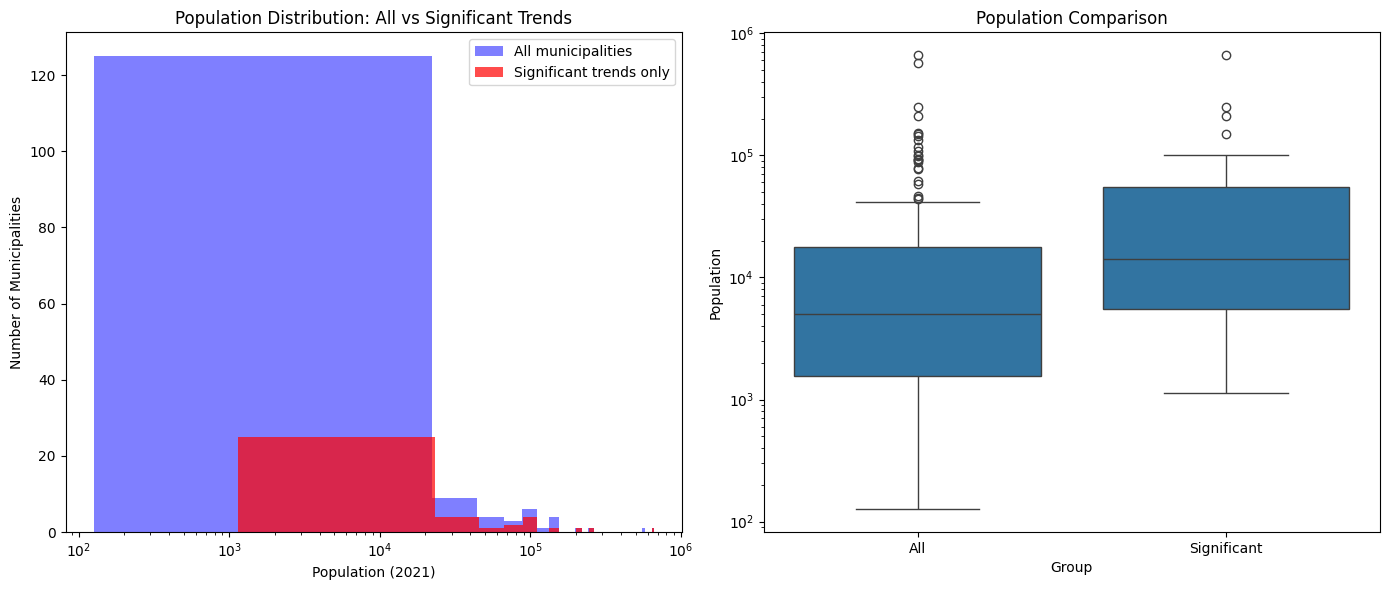

Mann-Whitney U test p-value: 0.0004
Median population (all): 5057
Median population (significant): 14224


In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get population data for cities with significant trends
population_data = tidy_all_data[
    (tidy_all_data['Municipality_Name'].isin(cities_for_decoupling)) & 
    (tidy_all_data['Metric'] == 'Population') & 
    (tidy_all_data['Year'] == 2021)  # or use 2021 for most recent
]

# Get population for ALL cities for comparison
all_population = tidy_all_data[
    (tidy_all_data['Metric'] == 'Population') & 
    (tidy_all_data['Year'] == 2021)
]

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution plot
ax1 = axes[0]
ax1.hist(all_population['Value'], bins=30, alpha=0.5, label='All municipalities', color='blue')
ax1.hist(population_data['Value'], bins=30, alpha=0.7, label='Significant trends only', color='red')
ax1.set_xlabel('Population (2021)')
ax1.set_ylabel('Number of Municipalities')
ax1.set_title('Population Distribution: All vs Significant Trends')
ax1.legend()
ax1.set_xscale('log')  # Log scale for better visualization

# Box plot comparison
ax2 = axes[1]
comparison_df = pd.DataFrame({
    'Population': list(all_population['Value']) + list(population_data['Value']),
    'Group': ['All'] * len(all_population) + ['Significant'] * len(population_data)
})
sns.boxplot(data=comparison_df, x='Group', y='Population', ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Population Comparison')

plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(all_population['Value'], population_data['Value'])
print(f"Mann-Whitney U test p-value: {p_value:.4f}")
print(f"Median population (all): {all_population['Value'].median():.0f}")
print(f"Median population (significant): {population_data['Value'].median():.0f}")

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/329665994.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  elasticity = emissions_change / wellbeing_change



Decoupling Analysis - All Cities:
Decoupling_Category
Strong decoupling                127
Expansive negative decoupling    109
Weak decoupling                   25
Strong negative decoupling        20
Recessive decoupling              17
Expansive coupling                13
Weak negative decoupling           1
Name: count, dtype: int64

Mean Tapio Index: 8.15

Decoupling Analysis - Significant Trends Only:
Decoupling_Category
Expansive negative decoupling    36
Strong decoupling                33
Expansive coupling                7
Weak decoupling                   4
Name: count, dtype: int64

Mean Tapio Index: 0.79


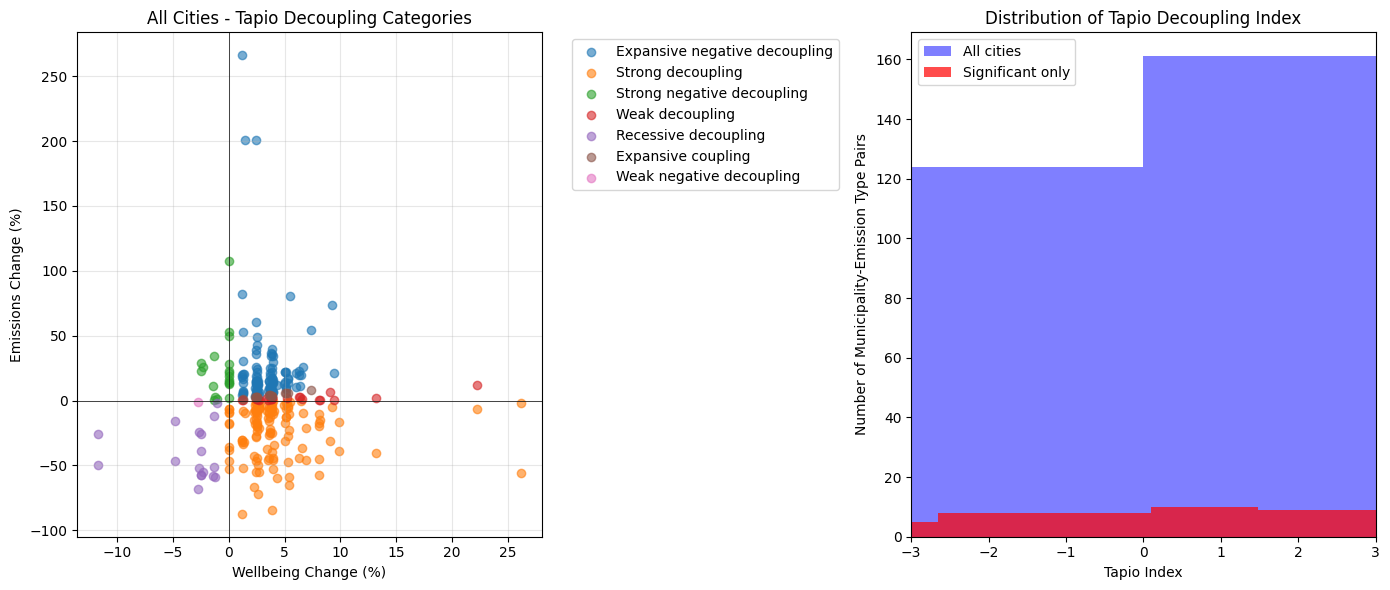

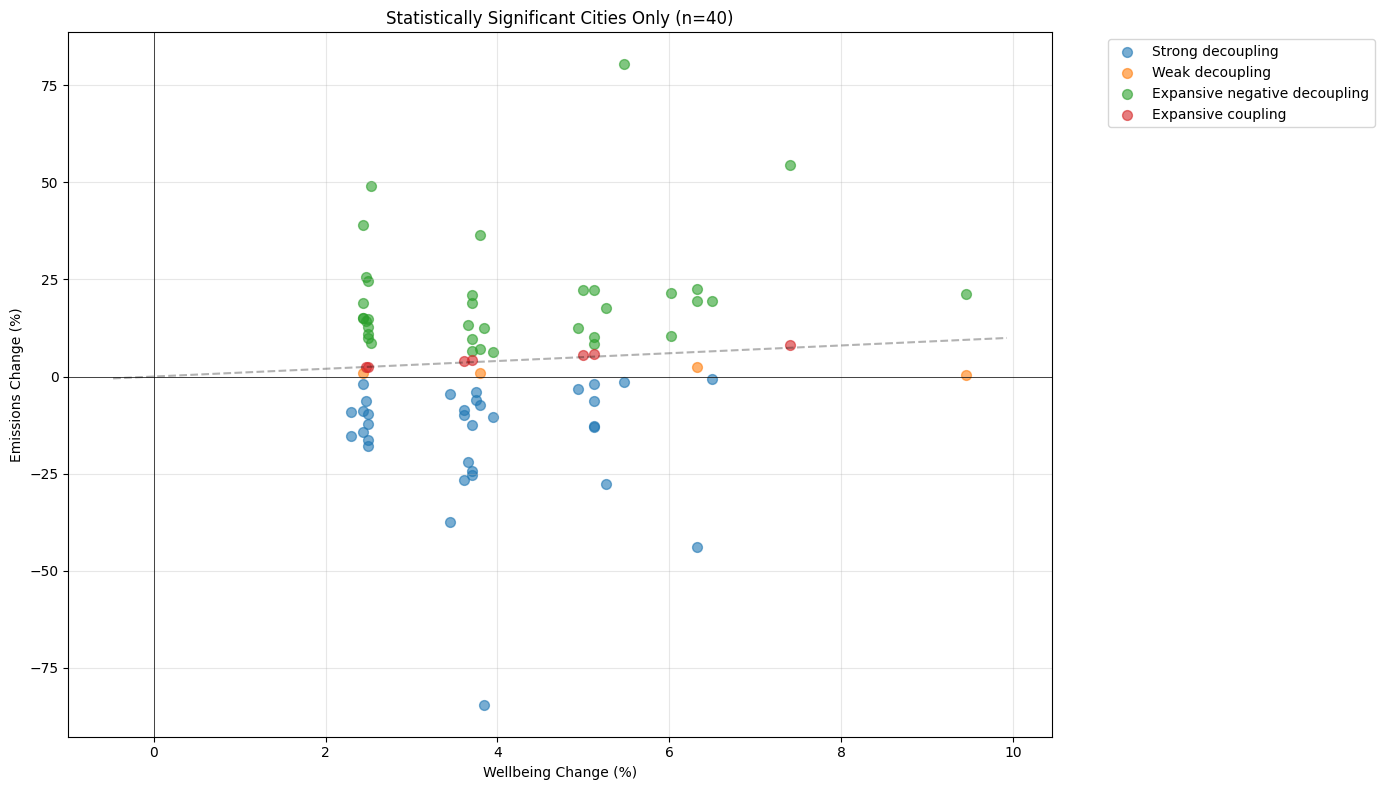

In [118]:
def calculate_tapio_index(emissions_change, wellbeing_change):
    """
    Calculate Tapio decoupling index
    Index = (% change in emissions) / (% change in wellbeing)
    """
    if abs(wellbeing_change) < 0.01:  # Avoid division by near-zero
        return np.nan
    return emissions_change / wellbeing_change

def categorize_tapio_decoupling(emissions_change, wellbeing_change):
    """
    Categorize based on Tapio (2005) framework using elasticity
    Elasticity = (% change in emissions) / (% change in GDP/wellbeing)
    """
    
    elasticity = emissions_change / wellbeing_change
    # Also cap extreme elasticity values to prevent outliers
    elasticity = max(-1000, min(1000, elasticity))
    # Handle near-zero wellbeing change
    if abs(wellbeing_change) < 0.01:
        if abs(emissions_change) < 0.01:
            return "No change", 0
        elif emissions_change > 0:
            return "Strong negative decoupling", elasticity
        else:
            return "Strong decoupling", elasticity
    
    # Quadrant 1: Both positive (growth)
    if wellbeing_change > 0 and emissions_change > 0:
        if 0.8 <= elasticity <= 1.2:
            return "Expansive coupling", elasticity
        elif elasticity < 0.8:
            return "Weak decoupling", elasticity
        else:  # elasticity > 1.2
            return "Expansive negative decoupling", elasticity
    
    # Quadrant 2: GDP positive, emissions negative
    elif wellbeing_change > 0 and emissions_change < 0:
        return "Strong decoupling", elasticity
    
    # Quadrant 3: Both negative (recession)
    elif wellbeing_change < 0 and emissions_change < 0:
        # Note: When both are negative, elasticity is positive
        # Higher elasticity means emissions falling faster than GDP
        if 0.8 <= elasticity <= 1.2:
            return "Recessive coupling", elasticity
        elif elasticity > 1.2:
            return "Recessive decoupling", elasticity
        else:  # elasticity < 0.8
            return "Weak negative decoupling", elasticity
    
    # Quadrant 4: GDP negative, emissions positive
    else:  # wellbeing_change < 0 and emissions_change > 0
        return "Strong negative decoupling", elasticity
    

# Calculate for all cities or just significant ones
def analyze_decoupling(tidy_data, municipality_list=None):
    """
    Calculate decoupling for specified municipalities with appropriate year ranges
    """
    if municipality_list is None:
        municipality_list = tidy_data['Municipality_Name'].unique()
    
    results = []
    
    # Define appropriate years for each metric
    emissions_start_years = [2007, 2010]
    emissions_end_years = [2017, 2018, 2019, 2020]
    cwb_start_year = [2011]  # or [2006] if you want longer term
    cwb_end_year = [2021]
    
    for city in municipality_list:
        city_data = tidy_data[tidy_data['Municipality_Name'] == city]
        
        # Calculate changes for each metric
        metrics_changes = {}
        
        # Handle emissions with their years
        for metric in ['Transportation_Emissions', 'Utility_Emissions']:
            metric_data = city_data[city_data['Metric'] == metric]
            
            start_vals = metric_data[metric_data['Year'].isin(emissions_start_years)]['Value'].dropna()
            end_vals = metric_data[metric_data['Year'].isin(emissions_end_years)]['Value'].dropna()
            
            if len(start_vals) > 0 and len(end_vals) > 0:
                start_mean = start_vals.mean()
                end_mean = end_vals.mean()
                if start_mean != 0:
                    percent_change = ((end_mean - start_mean) / start_mean) * 100
                    metrics_changes[metric] = percent_change
        
        # Handle CWB with its available years
        cwb_data = city_data[city_data['Metric'] == 'CWB']
        cwb_start_vals = cwb_data[cwb_data['Year'].isin(cwb_start_year)]['Value'].dropna()
        cwb_end_vals = cwb_data[cwb_data['Year'].isin(cwb_end_year)]['Value'].dropna()
        
        if len(cwb_start_vals) > 0 and len(cwb_end_vals) > 0:
            cwb_start_mean = cwb_start_vals.mean()
            cwb_end_mean = cwb_end_vals.mean()
            if cwb_start_mean != 0:
                cwb_percent_change = ((cwb_end_mean - cwb_start_mean) / cwb_start_mean) * 100
                metrics_changes['CWB'] = cwb_percent_change
        
        # Calculate decoupling if we have the necessary data
        if 'CWB' in metrics_changes:
            cwb_change = metrics_changes['CWB']
            
            if 'Transportation_Emissions' in metrics_changes:
                transport_category, transport_tapio = categorize_tapio_decoupling(
                    metrics_changes['Transportation_Emissions'], cwb_change
                )
                results.append({
                    'Municipality_Name': city,
                    'Emissions_Type': 'Transportation',
                    'Emissions_Change_%': metrics_changes['Transportation_Emissions'],
                    'Wellbeing_Change_%': cwb_change,
                    'Tapio_Index': transport_tapio,
                    'Decoupling_Category': transport_category
                })
            
            if 'Utility_Emissions' in metrics_changes:
                utility_category, utility_tapio = categorize_tapio_decoupling(
                    metrics_changes['Utility_Emissions'], cwb_change
                )
                results.append({
                    'Municipality_Name': city,
                    'Emissions_Type': 'Utility',
                    'Emissions_Change_%': metrics_changes['Utility_Emissions'],
                    'Wellbeing_Change_%': cwb_change,
                    'Tapio_Index': utility_tapio,
                    'Decoupling_Category': utility_category
                })
    
    return pd.DataFrame(results)

# Analyze all cities
all_decoupling = analyze_decoupling(tidy_all_data)

# Analyze only statistically significant cities
significant_decoupling = analyze_decoupling(tidy_all_data, cities_for_decoupling)

# Compare results
print("\nDecoupling Analysis - All Cities:")
print(all_decoupling['Decoupling_Category'].value_counts())
print(f"\nMean Tapio Index: {all_decoupling['Tapio_Index'].mean():.2f}")

print("\nDecoupling Analysis - Significant Trends Only:")
print(significant_decoupling['Decoupling_Category'].value_counts())
print(f"\nMean Tapio Index: {significant_decoupling['Tapio_Index'].mean():.2f}")

# Visualize Tapio indices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot with Tapio categories
ax1 = axes[0]
for category in all_decoupling['Decoupling_Category'].unique():
    cat_data = all_decoupling[all_decoupling['Decoupling_Category'] == category]
    ax1.scatter(cat_data['Wellbeing_Change_%'], cat_data['Emissions_Change_%'],
               label=category, alpha=0.6)

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Wellbeing Change (%)')
ax1.set_ylabel('Emissions Change (%)')
ax1.set_title('All Cities - Tapio Decoupling Categories')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)


# Tapio index distribution
ax2 = axes[1]
ax2.hist(all_decoupling['Tapio_Index'].dropna(), bins=30, alpha=0.5, 
         label='All cities', color='blue')
if len(significant_decoupling) > 0:
    ax2.hist(significant_decoupling['Tapio_Index'].dropna(), bins=30, alpha=0.7,
            label='Significant only', color='red')
#ax2.axvline(x=0, color='green', linestyle='--', label='Perfect decoupling') this doesn't make sense, as 0 is when emissions don't change, which is not what we want 
#ax2.axvline(x=1, color='red', linestyle='--', label='Coupling')
ax2.set_xlabel('Tapio Index')
ax2.set_ylabel('Number of Municipality-Emission Type Pairs')
ax2.set_title('Distribution of Tapio Decoupling Index')
ax2.legend()
ax2.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

# Visualize significant municipalities only
fig, ax3 = plt.subplots(figsize=(14, 8))  # Fixed: removed the '1' parameter

# Scatter plot with categories - note the axes are corrected
for category in significant_decoupling['Decoupling_Category'].unique():
    cat_data = significant_decoupling[significant_decoupling['Decoupling_Category'] == category]
    ax3.scatter(cat_data['Wellbeing_Change_%'], cat_data['Emissions_Change_%'],  # Swapped these
               label=category, alpha=0.6, s=50)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Wellbeing Change (%)')  # Fixed label
ax3.set_ylabel('Emissions Change (%)')  # Fixed label
ax3.set_title(f'Statistically Significant Cities Only (n={len(significant_decoupling["Municipality_Name"].unique())})')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

# Add diagonal reference line for equal changes
x_range = ax3.get_xlim()
ax3.plot(x_range, x_range, 'k--', alpha=0.3, label='Equal change')

plt.tight_layout()
plt.show()

# Save results
all_decoupling.to_csv("../data/processed/tapio_decoupling_all.csv", index=False)
significant_decoupling.to_csv("../data/processed/tapio_decoupling_significant.csv", index=False)


Decoupling Analysis - All Cities:
Decoupling_Category
Expansive Negative Decoupling    118
Strong Decoupling                117
Weak Decoupling                   29
Recessive Decoupling              27
Strong Negative Decoupling        20
Recessive Coupling                 1
Name: count, dtype: int64

Mean Tapio Index: 4.48

Decoupling Analysis - Significant Trends Only:
Decoupling_Category
Expansive Negative Decoupling    42
Strong Decoupling                33
Weak Decoupling                   5
Name: count, dtype: int64

Mean Tapio Index: 0.80


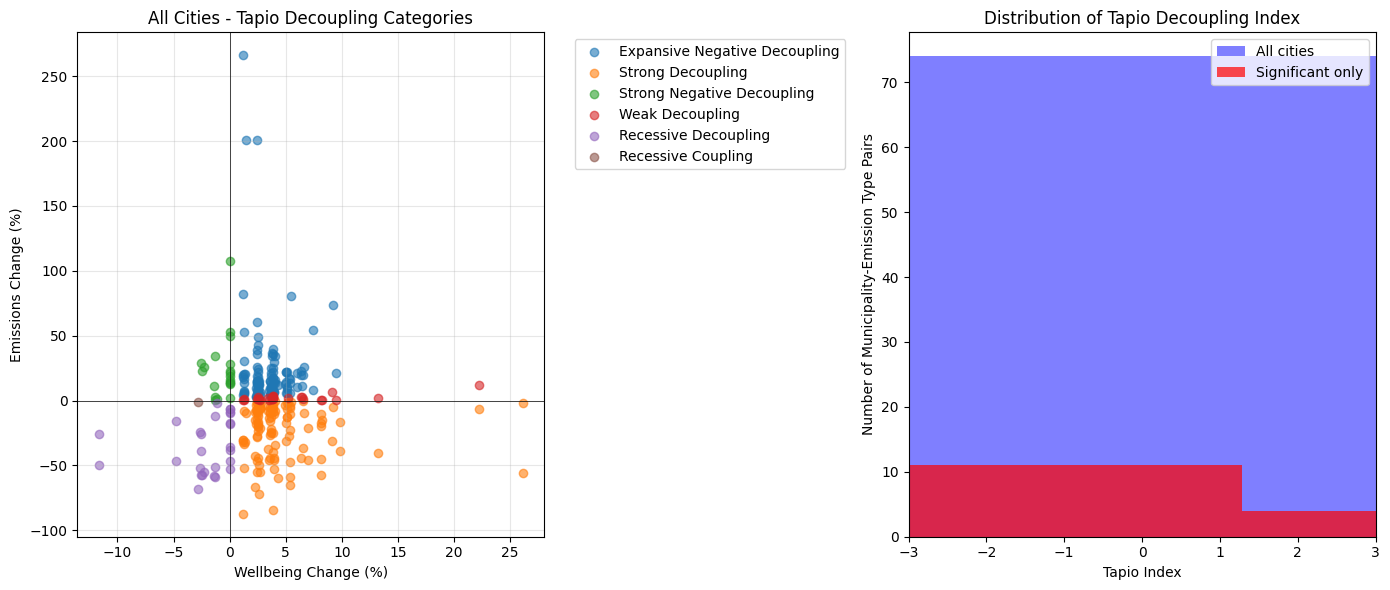

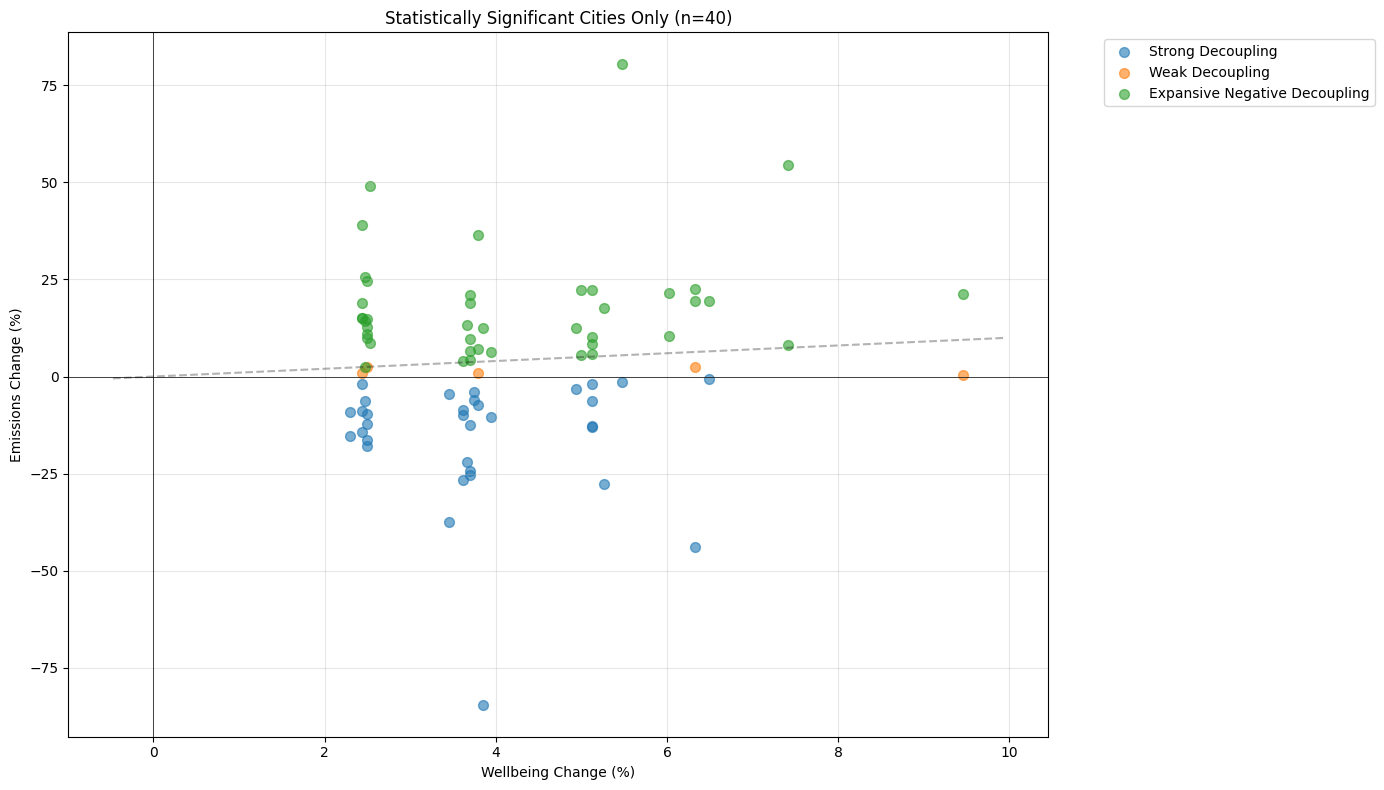

In [130]:
def calculate_new_decoupling_index(emissions_change, wellbeing_change):
    """
    Calculates a decoupling index based on the arithmetic difference ("gap")
    and categorizes the result using the established Tapio Decoupling terminology.

    The index is defined as: DGI = (% Change in Wellbeing) - (% Change in Emissions).

    This function avoids the original Tapio ratio calculation to prevent instability
    when the change in wellbeing is close to zero, but it uses the standard
    Tapio category names for consistency with the literature.
    
    Returns:
        tuple: (category_name, index_value)
    """
    # The Decoupling Gap Index (DGI)
    decoupling_index = wellbeing_change - emissions_change
    
    # Categorize based on the quadrant, using Tapio terminology
    if wellbeing_change > 0 and emissions_change < 0:
        # Ideal scenario: Wellbeing up, Emissions down.
        category = "Strong Decoupling"
        
    elif wellbeing_change > 0 and emissions_change >= 0:
        # Both are growing (Expansive state).
        if decoupling_index > 0: # Implies wellbeing_change > emissions_change
            category = "Weak Decoupling"
        else: # Implies wellbeing_change <= emissions_change
            category = "Expansive Negative Decoupling"
            
    elif wellbeing_change <= 0 and emissions_change < 0:
        # Both are declining (Recessive state).
        if decoupling_index > 0: # Implies wellbeing is falling slower than emissions
            category = "Recessive Decoupling"
        else: # Implies wellbeing is falling faster than (or same as) emissions
            category = "Recessive Coupling"
            
    else:  # wellbeing <= 0 and emissions >= 0
        # Worst-case scenario: Wellbeing down, Emissions up.
        # As per the diagram, this is "Strong Negative Decoupling".
        category = "Strong Negative Decoupling"
    
    return category, decoupling_index

# Calculate for all cities or just significant ones
def analyze_decoupling(tidy_data, municipality_list=None):
    """
    Calculate decoupling for specified municipalities with appropriate year ranges
    """
    if municipality_list is None:
        municipality_list = tidy_data['Municipality_Name'].unique()
    
    results = []
    
    # Define appropriate years for each metric
    emissions_start_years = [2007, 2010]
    emissions_end_years = [2017, 2018, 2019, 2020]
    cwb_start_year = [2011]  # or [2006] if you want longer term
    cwb_end_year = [2021]
    
    for city in municipality_list:
        city_data = tidy_data[tidy_data['Municipality_Name'] == city]
        
        # Calculate changes for each metric
        metrics_changes = {}
        
        # Handle emissions with their years
        for metric in ['Transportation_Emissions', 'Utility_Emissions']:
            metric_data = city_data[city_data['Metric'] == metric]
            
            start_vals = metric_data[metric_data['Year'].isin(emissions_start_years)]['Value'].dropna()
            end_vals = metric_data[metric_data['Year'].isin(emissions_end_years)]['Value'].dropna()
            
            if len(start_vals) > 0 and len(end_vals) > 0:
                start_mean = start_vals.mean()
                end_mean = end_vals.mean()
                if start_mean != 0:
                    percent_change = ((end_mean - start_mean) / start_mean) * 100
                    metrics_changes[metric] = percent_change
        
        # Handle CWB with its available years
        cwb_data = city_data[city_data['Metric'] == 'CWB']
        cwb_start_vals = cwb_data[cwb_data['Year'].isin(cwb_start_year)]['Value'].dropna()
        cwb_end_vals = cwb_data[cwb_data['Year'].isin(cwb_end_year)]['Value'].dropna()
        
        if len(cwb_start_vals) > 0 and len(cwb_end_vals) > 0:
            cwb_start_mean = cwb_start_vals.mean()
            cwb_end_mean = cwb_end_vals.mean()
            if cwb_start_mean != 0:
                cwb_percent_change = ((cwb_end_mean - cwb_start_mean) / cwb_start_mean) * 100
                metrics_changes['CWB'] = cwb_percent_change
        
        # Calculate decoupling if we have the necessary data
        if 'CWB' in metrics_changes:
            cwb_change = metrics_changes['CWB']
            
            if 'Transportation_Emissions' in metrics_changes:
                transport_category, transport_tapio = calculate_new_decoupling_index(
                    metrics_changes['Transportation_Emissions'], cwb_change
                )
                results.append({
                    'Municipality_Name': city,
                    'Emissions_Type': 'Transportation',
                    'Emissions_Change_%': metrics_changes['Transportation_Emissions'],
                    'Wellbeing_Change_%': cwb_change,
                    'Tapio_Index': transport_tapio,
                    'Decoupling_Category': transport_category
                })
            
            if 'Utility_Emissions' in metrics_changes:
                utility_category, utility_tapio = calculate_new_decoupling_index(
                    metrics_changes['Utility_Emissions'], cwb_change
                )
                results.append({
                    'Municipality_Name': city,
                    'Emissions_Type': 'Utility',
                    'Emissions_Change_%': metrics_changes['Utility_Emissions'],
                    'Wellbeing_Change_%': cwb_change,
                    'Tapio_Index': utility_tapio,
                    'Decoupling_Category': utility_category
                })
    
    return pd.DataFrame(results)

# Analyze all cities
all_decoupling = analyze_decoupling(tidy_all_data)

# Analyze only statistically significant cities
significant_decoupling = analyze_decoupling(tidy_all_data, cities_for_decoupling)

# Compare results
print("\nDecoupling Analysis - All Cities:")
print(all_decoupling['Decoupling_Category'].value_counts())
print(f"\nMean Tapio Index: {all_decoupling['Tapio_Index'].mean():.2f}")

print("\nDecoupling Analysis - Significant Trends Only:")
print(significant_decoupling['Decoupling_Category'].value_counts())
print(f"\nMean Tapio Index: {significant_decoupling['Tapio_Index'].mean():.2f}")

# Visualize Tapio indices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot with Tapio categories
ax1 = axes[0]
for category in all_decoupling['Decoupling_Category'].unique():
    cat_data = all_decoupling[all_decoupling['Decoupling_Category'] == category]
    ax1.scatter(cat_data['Wellbeing_Change_%'], cat_data['Emissions_Change_%'],
               label=category, alpha=0.6)

ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Wellbeing Change (%)')
ax1.set_ylabel('Emissions Change (%)')
ax1.set_title('All Cities - Tapio Decoupling Categories')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)


# Tapio index distribution
ax2 = axes[1]
ax2.hist(all_decoupling['Tapio_Index'].dropna(), bins=30, alpha=0.5, 
         label='All cities', color='blue')
if len(significant_decoupling) > 0:
    ax2.hist(significant_decoupling['Tapio_Index'].dropna(), bins=30, alpha=0.7,
            label='Significant only', color='red')
#ax2.axvline(x=0, color='green', linestyle='--', label='Perfect decoupling') this doesn't make sense, as 0 is when emissions don't change, which is not what we want 
#ax2.axvline(x=1, color='red', linestyle='--', label='Coupling')
ax2.set_xlabel('Tapio Index')
ax2.set_ylabel('Number of Municipality-Emission Type Pairs')
ax2.set_title('Distribution of Tapio Decoupling Index')
ax2.legend()
ax2.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

# Visualize significant municipalities only
fig, ax3 = plt.subplots(figsize=(14, 8))  # Fixed: removed the '1' parameter

# Scatter plot with categories - note the axes are corrected
for category in significant_decoupling['Decoupling_Category'].unique():
    cat_data = significant_decoupling[significant_decoupling['Decoupling_Category'] == category]
    ax3.scatter(cat_data['Wellbeing_Change_%'], cat_data['Emissions_Change_%'],  # Swapped these
               label=category, alpha=0.6, s=50)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax3.set_xlabel('Wellbeing Change (%)')  # Fixed label
ax3.set_ylabel('Emissions Change (%)')  # Fixed label
ax3.set_title(f'Statistically Significant Cities Only (n={len(significant_decoupling["Municipality_Name"].unique())})')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

# Add diagonal reference line for equal changes
x_range = ax3.get_xlim()
ax3.plot(x_range, x_range, 'k--', alpha=0.3, label='Equal change')

plt.tight_layout()
plt.show()

# Save results
all_decoupling.to_csv("../data/processed/tapio_decoupling_all.csv", index=False)
significant_decoupling.to_csv("../data/processed/tapio_decoupling_significant.csv", index=False)

In [110]:
print(all_decoupling['Tapio_Index'])

0         8.535475
1         5.842218
2         4.851539
3       -18.961606
4      1000.000000
          ...     
307      -3.049785
308      -0.084713
309       5.800980
310   -1000.000000
311   -1000.000000
Name: Tapio_Index, Length: 312, dtype: float64


average of two datapoints (2017 and 2020)
em<0, wel>0                      78
em>0, wel>0, wel<em              48

average of four datapoints 2017, 2018, 2019, 2020
em<0, wel>0                      82
em>0, wel>0, wel<em              43


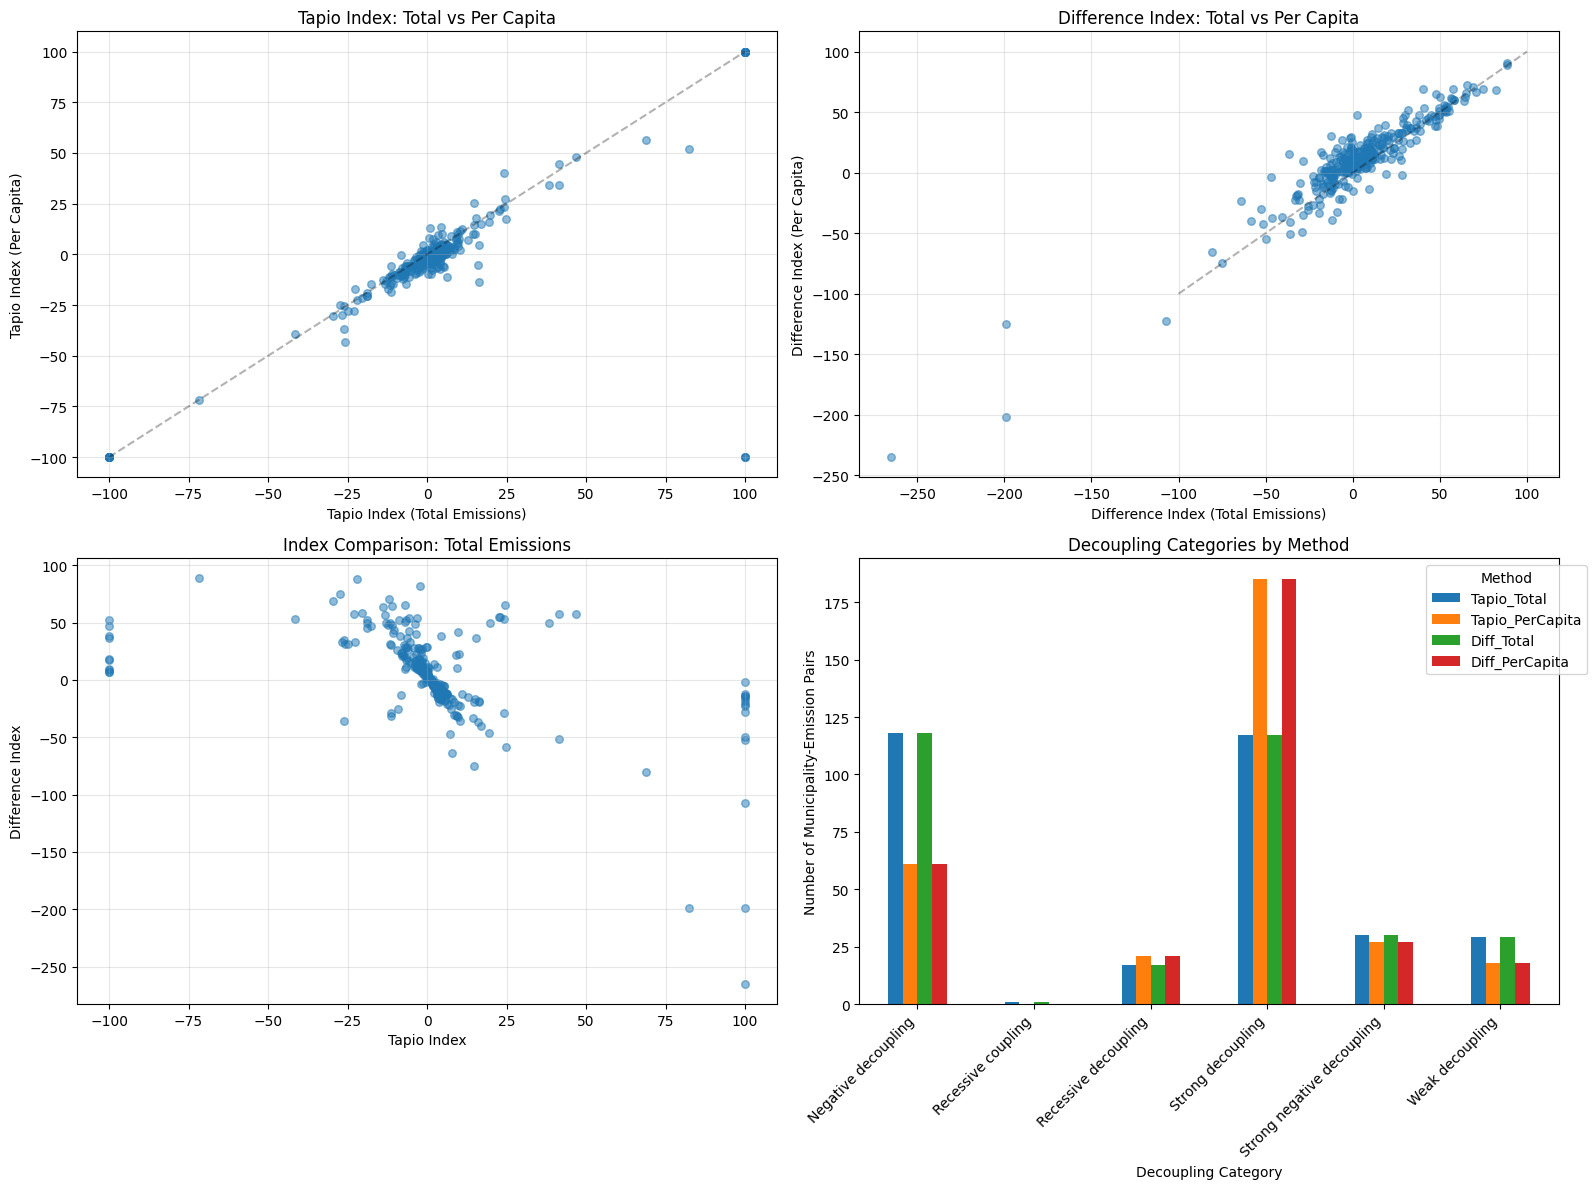


CORRELATION BETWEEN METHODS:
Total vs Per-capita (Tapio): 0.784
Total vs Per-capita (Diff): 0.940
Tapio vs Diff (Total): -0.505
Tapio vs Diff (Per-capita): -0.480

AGREEMENT BETWEEN INDICES:
Agreement for total emissions: 100.0%
Agreement for per-capita emissions: 100.0%

CITIES THAT CHANGE CLASSIFICATION (Total vs Per-capita):
Number of changes: 96

Examples:
   Municipality_Name   Emission_Type  Population_Change_%  \
1         Abbotsford         Utility            15.001835   
7          Armstrong         Utility            10.550363   
9           Ashcroft         Utility             2.579853   
11          Belcarra         Utility             6.677019   
16        Burns Lake  Transportation           -18.235584   
20    Campbell River  Transportation            13.894055   
24         Castlegar  Transportation             6.678608   
32        Chilliwack  Transportation            19.589150   
33        Chilliwack         Utility            19.589150   
36        Coldstream  Tran

In [137]:
def comprehensive_decoupling_comparison(tidy_data):
    """
    Compare decoupling using:
    1. Total vs per-capita emissions
    2. Tapio vs difference-based indices
    """
    
    # Define year ranges
    emissions_start_years = [2007, 2010]
    emissions_end_years = [2017, 2018, 2019, 2020]
    cwb_years = {'start': [2011], 'end': [2021]}
    pop_years = {'start': [2011], 'end': [2021]}
    
    results = []
    
    for city in tidy_data['Municipality_Name'].unique():
        city_data = tidy_data[tidy_data['Municipality_Name'] == city]
        
        # Get population data
        pop_data = city_data[city_data['Metric'] == 'Population']
        pop_start = pop_data[pop_data['Year'].isin(pop_years['start'])]['Value'].mean()
        pop_end = pop_data[pop_data['Year'].isin(pop_years['end'])]['Value'].mean()
        
        if pop_start > 0 and pop_end > 0:
            pop_change = ((pop_end - pop_start) / pop_start) * 100
        else:
            continue
        
        # Get CWB change
        cwb_data = city_data[city_data['Metric'] == 'CWB']
        cwb_start = cwb_data[cwb_data['Year'].isin(cwb_years['start'])]['Value'].mean()
        cwb_end = cwb_data[cwb_data['Year'].isin(cwb_years['end'])]['Value'].mean()
        
        if cwb_start > 0:
            cwb_change = ((cwb_end - cwb_start) / cwb_start) * 100
        else:
            continue
        
        # Process each emission type
        for emission_type in ['Transportation_Emissions', 'Utility_Emissions']:
            emission_data = city_data[city_data['Metric'] == emission_type]
            
            # Get emissions values
            em_start_vals = emission_data[emission_data['Year'].isin(emissions_start_years)]['Value']
            em_end_vals = emission_data[emission_data['Year'].isin(emissions_end_years)]['Value']
            
            if len(em_start_vals) > 0 and len(em_end_vals) > 0:
                em_start = em_start_vals.mean()
                em_end = em_end_vals.mean()
                
                # Total emissions change
                if em_start > 0:
                    total_em_change = ((em_end - em_start) / em_start) * 100
                else:
                    continue
                
                # Per capita emissions change
                pc_em_start = em_start / pop_start
                pc_em_end = em_end / pop_end
                if pc_em_start > 0:
                    pc_em_change = ((pc_em_end - pc_em_start) / pc_em_start) * 100
                else:
                    continue
                
                # Calculate both indices for total emissions
                # Tapio index
                if abs(cwb_change) > 0.01:
                    tapio_total = total_em_change / cwb_change
                    tapio_total = max(-100, min(100, tapio_total))  # Cap extremes
                else:
                    tapio_total = 100 if total_em_change > 0 else -100
                
                # Difference index
                diff_total = cwb_change - total_em_change
                
                # Calculate both indices for per-capita emissions
                if abs(cwb_change) > 0.001:
                    tapio_pc = pc_em_change / cwb_change
                    tapio_pc = max(-100, min(100, tapio_pc))
                else:
                    tapio_pc = 100 if pc_em_change > 0 else -100
                
                diff_pc = cwb_change - pc_em_change
                
                # Store results
                results.append({
                    'Municipality_Name': city,
                    'Emission_Type': emission_type.replace('_Emissions', ''),
                    'Population_Start': pop_start,
                    'Population_End': pop_end,
                    'Population_Change_%': pop_change,
                    'CWB_Change_%': cwb_change,
                    'Total_Emissions_Change_%': total_em_change,
                    'PerCapita_Emissions_Change_%': pc_em_change,
                    'Tapio_Index_Total': tapio_total,
                    'Tapio_Index_PerCapita': tapio_pc,
                    'Diff_Index_Total': diff_total,
                    'Diff_Index_PerCapita': diff_pc
                })
    
    return pd.DataFrame(results)

# Run the comparison
comparison_df = comprehensive_decoupling_comparison(tidy_all_data)

# Categorize based on different approaches
def categorize_by_index(row, index_col):
    """Categorize decoupling based on index value and changes"""
    cwb = row['CWB_Change_%']
    
    if 'Total' in index_col:
        em = row['Total_Emissions_Change_%']
    else:
        em = row['PerCapita_Emissions_Change_%']
    
    if cwb > 0 and em < 0:
        return "Strong decoupling"
    elif cwb > 0 and em > 0:
        if 'Diff' in index_col:
            return "Weak decoupling" if row[index_col] > 0 else "Negative decoupling"
        else:  # Tapio
            return "Weak decoupling" if row[index_col] < 1 else "Negative decoupling"
    elif cwb < 0 and em < 0:
        if 'Diff' in index_col:
            return "Recessive decoupling" if row[index_col] > 0 else "Recessive coupling"
        else:  # Tapio
            return "Recessive decoupling" if row[index_col] > 1 else "Recessive coupling"
    else:
        return "Strong negative decoupling"

# Add categories
for index_type in ['Tapio_Index_Total', 'Tapio_Index_PerCapita', 
                   'Diff_Index_Total', 'Diff_Index_PerCapita']:
    comparison_df[f'Category_{index_type}'] = comparison_df.apply(
        lambda x: categorize_by_index(x, index_type), axis=1
    )

# Comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total vs Per-capita using Tapio
ax1 = axes[0, 0]
ax1.scatter(comparison_df['Tapio_Index_Total'], 
           comparison_df['Tapio_Index_PerCapita'],
           alpha=0.5, s=30)
ax1.plot([-100, 100], [-100, 100], 'k--', alpha=0.3)
ax1.set_xlabel('Tapio Index (Total Emissions)')
ax1.set_ylabel('Tapio Index (Per Capita)')
ax1.set_title('Tapio Index: Total vs Per Capita')
ax1.grid(True, alpha=0.3)

# Plot 2: Total vs Per-capita using Difference
ax2 = axes[0, 1]
ax2.scatter(comparison_df['Diff_Index_Total'], 
           comparison_df['Diff_Index_PerCapita'],
           alpha=0.5, s=30)
ax2.plot([-100, 100], [-100, 100], 'k--', alpha=0.3)
ax2.set_xlabel('Difference Index (Total Emissions)')
ax2.set_ylabel('Difference Index (Per Capita)')
ax2.set_title('Difference Index: Total vs Per Capita')
ax2.grid(True, alpha=0.3)

# Plot 3: Tapio vs Difference for Total Emissions
ax3 = axes[1, 0]
ax3.scatter(comparison_df['Tapio_Index_Total'], 
           comparison_df['Diff_Index_Total'],
           alpha=0.5, s=30)
ax3.set_xlabel('Tapio Index')
ax3.set_ylabel('Difference Index')
ax3.set_title('Index Comparison: Total Emissions')
ax3.grid(True, alpha=0.3)

# Plot 4: Category comparison
ax4 = axes[1, 1]
category_comparison = pd.DataFrame({
    'Tapio_Total': comparison_df['Category_Tapio_Index_Total'].value_counts(),
    'Tapio_PerCapita': comparison_df['Category_Tapio_Index_PerCapita'].value_counts(),
    'Diff_Total': comparison_df['Category_Diff_Index_Total'].value_counts(),
    'Diff_PerCapita': comparison_df['Category_Diff_Index_PerCapita'].value_counts()
}).fillna(0)

category_comparison.plot(kind='bar', ax=ax4)
ax4.set_title('Decoupling Categories by Method')
ax4.set_xlabel('Decoupling Category')
ax4.set_ylabel('Number of Municipality-Emission Pairs')
ax4.legend(title='Method', bbox_to_anchor=(1.05, 1))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nCORRELATION BETWEEN METHODS:")
print(f"Total vs Per-capita (Tapio): {comparison_df['Tapio_Index_Total'].corr(comparison_df['Tapio_Index_PerCapita']):.3f}")
print(f"Total vs Per-capita (Diff): {comparison_df['Diff_Index_Total'].corr(comparison_df['Diff_Index_PerCapita']):.3f}")
print(f"Tapio vs Diff (Total): {comparison_df['Tapio_Index_Total'].corr(comparison_df['Diff_Index_Total']):.3f}")
print(f"Tapio vs Diff (Per-capita): {comparison_df['Tapio_Index_PerCapita'].corr(comparison_df['Diff_Index_PerCapita']):.3f}")

# Agreement analysis
comparison_df['Total_Agreement'] = (comparison_df['Category_Tapio_Index_Total'] == 
                                    comparison_df['Category_Diff_Index_Total'])
comparison_df['PerCapita_Agreement'] = (comparison_df['Category_Tapio_Index_PerCapita'] == 
                                        comparison_df['Category_Diff_Index_PerCapita'])

print(f"\nAGREEMENT BETWEEN INDICES:")
print(f"Agreement for total emissions: {comparison_df['Total_Agreement'].mean():.1%}")
print(f"Agreement for per-capita emissions: {comparison_df['PerCapita_Agreement'].mean():.1%}")

# Show which cities change classification
classification_changes = comparison_df[
    comparison_df['Category_Tapio_Index_Total'] != comparison_df['Category_Tapio_Index_PerCapita']
][['Municipality_Name', 'Emission_Type', 'Population_Change_%', 
   'Category_Tapio_Index_Total', 'Category_Tapio_Index_PerCapita']]

print(f"\nCITIES THAT CHANGE CLASSIFICATION (Total vs Per-capita):")
print(f"Number of changes: {len(classification_changes)}")
if len(classification_changes) > 0:
    print("\nExamples:")
    print(classification_changes.head(10))

# Save comparison results
comparison_df.to_csv("../data/processed/decoupling_method_comparison.csv", index=False)

In [119]:
#get coordinates of each city in the bc-gazetteer-2024-06-13.csv file in the raw data folder
gazeteer = pd.read_csv(os.path.join('..','data','raw','bc-gazetteer-2024-06-13.csv'))
# Filter for communities in the final analysis data
gazeteer_filtered = gazeteer[gazeteer['Official Name'].isin(tidy_all_data['Municipality_Name']) & gazeteer['Feature Type'].isin(['City', 'Town', 'District Municipality', 'District Municipality (1)', 'Village (1)','Resort Municipality', 'Mountain Resort Municipality'])]


In [120]:
#print all unique official names in the gazeteer_filtered dataframe
print("Unique official names in gazeteer_filtered:")
print(gazeteer_filtered['Official Name'].unique())
#count unique official names
print(f"Total unique official names in gazeteer_filtered: {gazeteer_filtered['Official Name'].nunique()}")
#figure out which communities are missing coordinates
missing_coordinates = tidy_all_data[~tidy_all_data['Municipality_Name'].isin(gazeteer_filtered['Official Name'])]
print(f"Communities missing coordinates: {len(missing_coordinates)}")
print("Missing communities:")
for community in missing_coordinates['Municipality_Name'].unique():
    print(f"  {community}")

Unique official names in gazeteer_filtered:
['Abbotsford' 'Alert Bay' 'Anmore' 'Armstrong' 'Ashcroft' 'Barriere'
 'Belcarra' 'Bowen Island' 'Burnaby' 'Burns Lake' 'Cache Creek'
 'Campbell River' 'Canal Flats' 'Castlegar' 'Central Saanich' 'Chase'
 'Chetwynd' 'Chilliwack' 'Clearwater' 'Clinton' 'Coldstream' 'Colwood'
 'Comox' 'Coquitlam' 'Courtenay' 'Cranbrook' 'Creston' 'Cumberland'
 'Dawson Creek' 'Delta' 'Duncan' 'Elkford' 'Enderby' 'Esquimalt' 'Fernie'
 'Fort St. James' 'Fort St. John' 'Fraser Lake' 'Fruitvale' 'Gibsons'
 'Gold River' 'Golden' 'Grand Forks' 'Granisle' 'Greenwood'
 'Harrison Hot Springs' 'Hazelton' 'Highlands' 'Hope' 'Houston'
 "Hudson's Hope" 'Invermere' 'Kamloops' 'Kaslo' 'Kelowna' 'Kent'
 'Keremeos' 'Kimberley' 'Kitimat' 'Ladysmith' 'Lake Country'
 'Lake Cowichan' 'Langford' 'Lantzville' 'Lillooet' 'Lions Bay'
 'Logan Lake' 'Lumby' 'Lytton' 'Mackenzie' 'Maple Ridge' 'Masset'
 'McBride' 'Merritt' 'Metchosin' 'Midway' 'Mission' 'Montrose' 'Nakusp'
 'Nanaimo' 'Nelson

In [121]:
# Manual mapping for missing communities using both name and feature type
name_featuretype_corrections = {
    "Langley City": ("Langley", "City"),
    "Langley Township": ("Langley", "District Municipality (1)"),
    "North Vancouver City": ("North Vancouver", "City"),
    "North Vancouver District": ("North Vancouver", "District Municipality (1)"),
    "One Hundred Mile House": ("100 Mile House", "District Municipality (1)"),
    "Sun Peaks Mountain Resort": ("Sun Peaks", "Mountain Resort Municipality"),
    "West Kelowna": ("West Kelowna, City of", "City"),
    "Queen Charlotte": ("Queen Charlotte", "Post Office"),
    "Sechelt IGD": ("Sechelt Indian Government District", "Indian Government District"),
    "Northern Rockies" :("Northern Rockies Regional Municipality","District Municipality (1)") 
}

missing_coords = []
for community, (gaz_name, feature_type) in name_featuretype_corrections.items():
    if feature_type:
        match = gazeteer[(gazeteer['Official Name'].str.lower() == gaz_name.lower()) &
                         (gazeteer['Feature Type'].str.lower() == feature_type.lower())]
    else:
        match = gazeteer[gazeteer['Official Name'].str.lower() == gaz_name.lower()]
    if not match.empty:
        feature_type = match.iloc[0]['Feature Type']
        lat = match.iloc[0]['LatDD']
        lon = match.iloc[0]['LongDD']
        datum = match.iloc[0]['Datum']
        missing_coords.append({'Official Name': community, 'Feature Type': feature_type, 'Datum': datum, 'LatDD': lat, 'LongDD': lon})
    else:
        print(f"Not found in gazeteer: {community} -> {gaz_name} ({feature_type})")

missing_coords_df = pd.DataFrame(missing_coords)
print(missing_coords_df)

               Official Name                  Feature Type  Datum      LatDD  \
0               Langley City                          City  WGS84  49.102500   
1           Langley Township     District Municipality (1)  WGS84  49.120278   
2       North Vancouver City                          City  WGS84  49.320556   
3   North Vancouver District     District Municipality (1)  WGS84  49.336111   
4     One Hundred Mile House     District Municipality (1)  WGS84  51.642778   
5  Sun Peaks Mountain Resort  Mountain Resort Municipality  WGS84  50.884444   
6               West Kelowna                          City  WGS84  49.830000   
7            Queen Charlotte                   Post Office  WGS84  53.253878   
8                Sechelt IGD    Indian Government District  WGS84  49.478960   
9           Northern Rockies     District Municipality (1)  WGS84  58.803889   

       LongDD  
0 -122.658056  
1 -122.659722  
2 -123.073889  
3 -123.078056  
4 -121.295556  
5 -119.879444  
6 -119.

In [122]:
#add missing communities to gazeteer_filtered
gazeteer_filtered = pd.concat([gazeteer_filtered, missing_coords_df]).reset_index(drop=True)
gazeteer_filtered.head()
#gazeteer_filtered.tail(20)

,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
0,Abbotsford,City,1.0,92G/1,49 03 07 N,122 19 45 W,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),3.0,92L/10,50 35 01 N,126 55 40 W,WGS84,50.583889,-126.927778
2,Anmore,Village (1),3.0,92G/7,49 18 51 N,122 51 23 W,WGS84,49.314444,-122.856389
3,Armstrong,City,1.0,82L/6,50 26 53 N,119 11 48 W,WGS84,50.448333,-119.196667
4,Ashcroft,Village (1),3.0,92I/11,50 43 16 N,121 17 00 W,WGS84,50.721389,-121.283611


In [123]:
gazeteer_filtered.tail(2)

,Official Name,Feature Type,Feature Type Code,Mapsheet,Latitude,Longitude,Datum,LatDD,LongDD
160,Sechelt IGD,Indian Government District,NaN,NaN,NaN,NaN,WGS84,49.478960,-123.742985
161,Northern Rockies,District Municipality (1),NaN,NaN,NaN,NaN,WGS84,58.803889,-122.706667


In [124]:
#check if the gazeteer_filtered dataframe has all the communities from final_analysis_data
print(f"Total communities in final_analysis_data: {len(final_analysis_data['Municipality_Name'].unique())}")
print(f"Total communities in gazeteer_filtered: {len(gazeteer_filtered['Official Name'].unique())}")
missing_communities =  set(gazeteer_filtered['Official Name'].unique()) - set(final_analysis_data['Municipality_Name'].unique())
print(f"Missing communities in gazeteer_filtered: {len(missing_communities)}")
if missing_communities:
    print("Missing communities:")
    for community in missing_communities:
        print(f"  {community}")

Total communities in final_analysis_data: 161
Total communities in gazeteer_filtered: 162
Missing communities in gazeteer_filtered: 1
Missing communities:
  Northern Rockies Regional Municipality


In [125]:
#find duplicates
duplicates = gazeteer_filtered[gazeteer_filtered.duplicated(subset=['Official Name'], keep=False)]
print(f"Total duplicates found: {len(duplicates)}")
if not duplicates.empty:
    print("Duplicate entries:")
    for index, row in duplicates.iterrows():
        print(f"  {row['Official Name']} (Index: {index})")


Total duplicates found: 0


In [126]:
#extract official name, feature type, datum, latitude and longitude from gazeteer_filtered
gazeteer_final = gazeteer_filtered[['Official Name', 'Feature Type', 'Datum', 'LatDD', 'LongDD']].copy()
gazeteer_final.rename(columns={
    'Official Name': 'Municipality_Name',
    'Feature Type': 'Feature_Type',
    'Datum': 'Datum',
    'LatDD': 'Latitude',
    'LongDD': 'Longitude'
}, inplace=True)
# Save the gazeteer_final dataframe to a CSV file in the processed data folder
gazeteer_final.to_csv(os.path.join('..', 'data', 'processed', 'gazeteer_final.csv'), index=False)

In [127]:
gazeteer_final.head(2)

,Municipality_Name,Feature_Type,Datum,Latitude,Longitude
0,Abbotsford,City,WGS84,49.052222,-122.329167
1,Alert Bay,Village (1),WGS84,50.583889,-126.927778


In [128]:
#merge the gazeteer data with the final_analysis_data
final_analysis_data_with_coords = pd.concat(tidy_all_data, gazeteer_final, on='Municipality_Name')
# Save the final analysis data with coordinates to a CSV file in the processed data folder
final_analysis_data_with_coords.to_csv(os.path.join('..', 'data', 'processed', 'final_analysis_data_with_coords.csv'), index=False)
# Display the final analysis data with coordinates
print("Final analysis data with coordinates:")
print(final_analysis_data_with_coords.head())

TypeError: concat() got an unexpected keyword argument 'on'

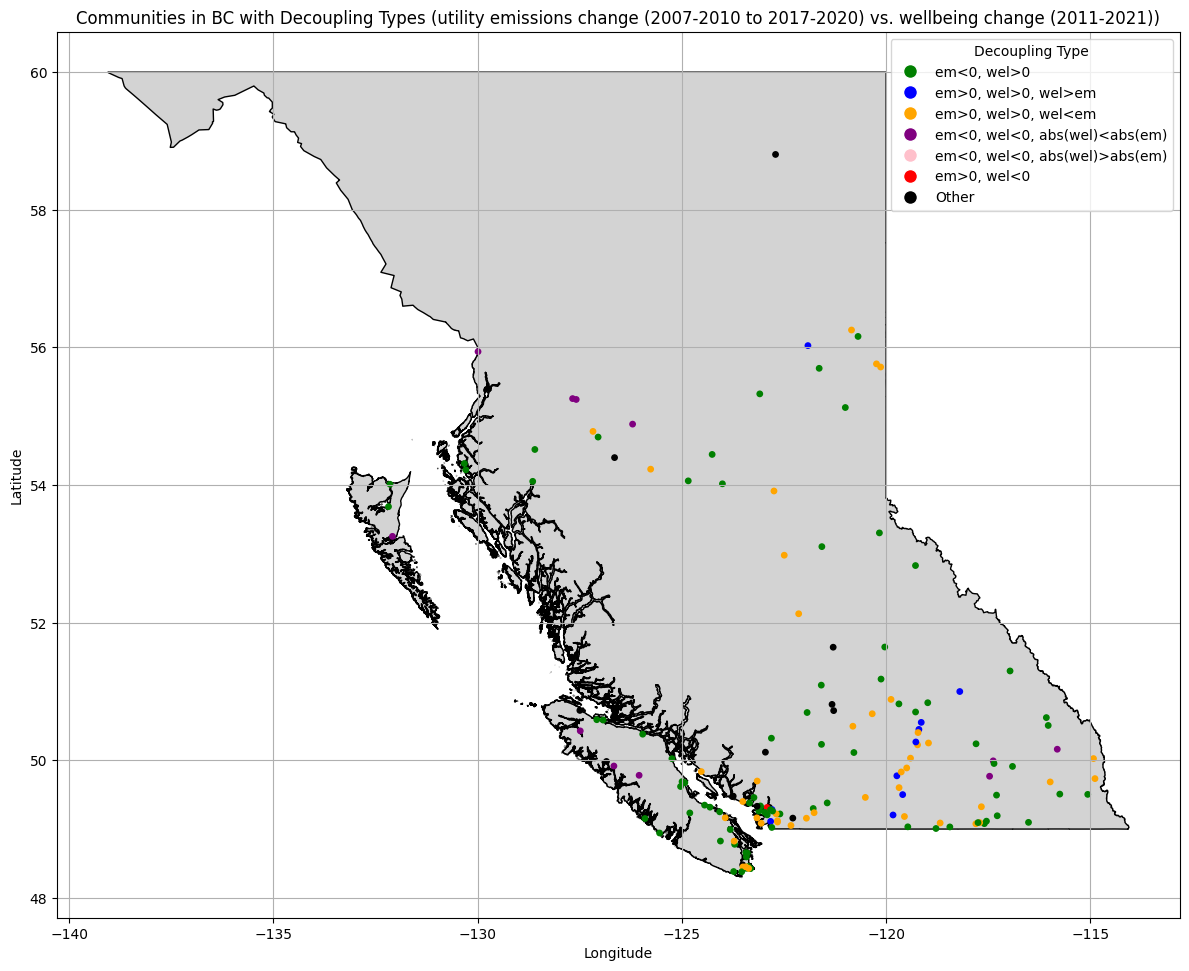

In [72]:
#plot the final analysis data with coordinates on a map of BC, with shapefile located in the raw dataset subfolder BC_Boundary as BC_Boundary.shp
import geopandas as gpd
# Load the shapefile for BC boundaries
bc_boundaries = gpd.read_file(os.path.join('..', 'data', 'raw', 'BC_Boundary', 'BC_Boundary.shp'))
# Convert the final analysis data with coordinates to a GeoDataFrame
final_analysis_gdf = gpd.GeoDataFrame(
    final_analysis_data_with_coords,
    geometry=gpd.points_from_xy(final_analysis_data_with_coords['Longitude'], final_analysis_data_with_coords['Latitude']),
    crs='EPSG:4326'  # WGS84 coordinate system
)

decoupling_colors = {
    'em<0, wel>0': 'green',
    'em>0, wel>0, wel>em': 'blue',
    'em>0, wel>0, wel<em': 'orange',
    'em<0, wel<0, abs(wel)<abs(em)': 'purple',
    'em<0, wel<0, abs(wel)>abs(em)': 'pink',
    'em>0, wel<0': 'red',
    'Other': 'black'  # Default color for any other cases
}


final_analysis_gdf['color'] = final_analysis_gdf['utility_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (utility emissions change (2007-2010 to 2017-2020) vs. wellbeing change (2011-2021))')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

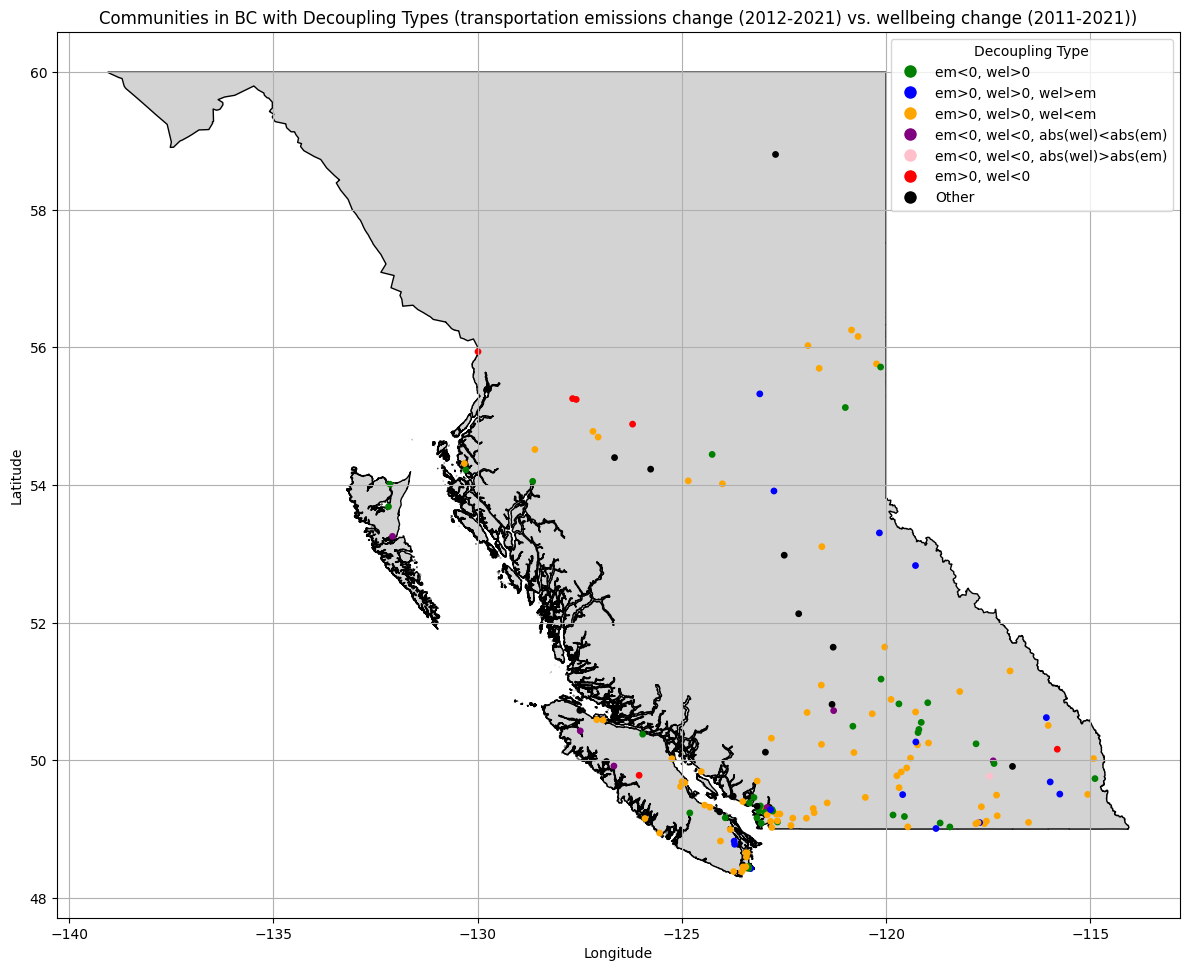

In [73]:
final_analysis_gdf['color'] = final_analysis_gdf['transportation_emissions_decoupling_type'].map(decoupling_colors)

plt.figure(figsize=(12, 12))
bc_boundaries.plot(ax=plt.gca(), color='lightgrey', edgecolor='black')
#plot the map with legend showing each color based on decoupling type
final_analysis_gdf.plot(ax=plt.gca(), marker='o', color=final_analysis_gdf['color'], markersize=15, label='Communities')
# Create a custom legend
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) for label, color in decoupling_colors.items()]
plt.legend(handles=handles, title='Decoupling Type', loc='upper right')

plt.title('Communities in BC with Decoupling Types (transportation emissions change (2012-2021) vs. wellbeing change (2011-2021))')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [74]:
# Find name of communities in the worse case scenario of transportation emissions decoupling
worse_case_communities = final_analysis_gdf[final_analysis_gdf['transportation_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Municipality_Name'], worse_case_communities['transportation_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['Census Population 2011'])


12      Canal Flats
40       Gold River
43         Granisle
46         Hazelton
84     New Hazelton
135         Stewart
Name: Municipality_Name, dtype: object 12     29.087871
40     23.069154
43     11.529057
46     26.181138
84     34.634794
135     2.424826
Name: transportation_emissions_percent_change, dtype: float64 12    -2.531646
40    -2.500000
43    -1.408451
46    -2.298851
84    -1.333333
135   -1.265823
Name: cwb_percent_change, dtype: float64 12      715.0
40     1267.0
43      303.0
46      270.0
84      666.0
135     494.0
Name: Census Population 2011, dtype: float64


In [75]:
# Find name of communities in the worse case scenario of utility emissions decoupling
worse_case_communities = final_analysis_gdf[final_analysis_gdf['utility_emissions_decoupling_type'] == 'em>0, wel<0']
print(worse_case_communities['Municipality_Name'], worse_case_communities['utility_emissions_percent_change'], worse_case_communities['cwb_percent_change'], worse_case_communities['Census Population 2011'])


6    Belcarra
Name: Municipality_Name, dtype: object 6    1.283684
Name: utility_emissions_percent_change, dtype: float64 6   -1.098901
Name: cwb_percent_change, dtype: float64 6    644.0
Name: Census Population 2011, dtype: float64


Next steps:
1) Manually create municipal shapefile boundaries for the municipalities that are missing from the data
2) Find if there is a way to include Northern Rockies
3) decide to include seachelt IDG or exclude it
4) add emissions of facilities outside of municipal boundaries to nearest municipality 




1) (DONE) map the coupling vs decoupling of municipalities across BC
    a) (DONE) find coordinates of each municipality
2) (DONE) add transportation emissions to building emissions and redo analysis
    a) show road networks in the map and power line networks as well
3) segregate analysis by sector (industry vs residential)
4) try using emissions from 2007 with wellbeing from 2006?
5) compare the disaggregated components of the wellbeing index (e.g. income vs. education vs. housing) with the emissions 
6) compare coupling/decoupling with climate action plans in LGCAP and with climate impacts to see which communities are most vulnerable
7) use actual census data (e.g. mean income value for community, education level) and make a random forest model that predicts coupling/decoupling using the census data?
8) see if the poorest communities that had lowest wellbeing to start with are the ones going through negative decoupling
9) subtract wellbeing change from emissions change to have a number that measures the extent of decoupling, or use taipa equation


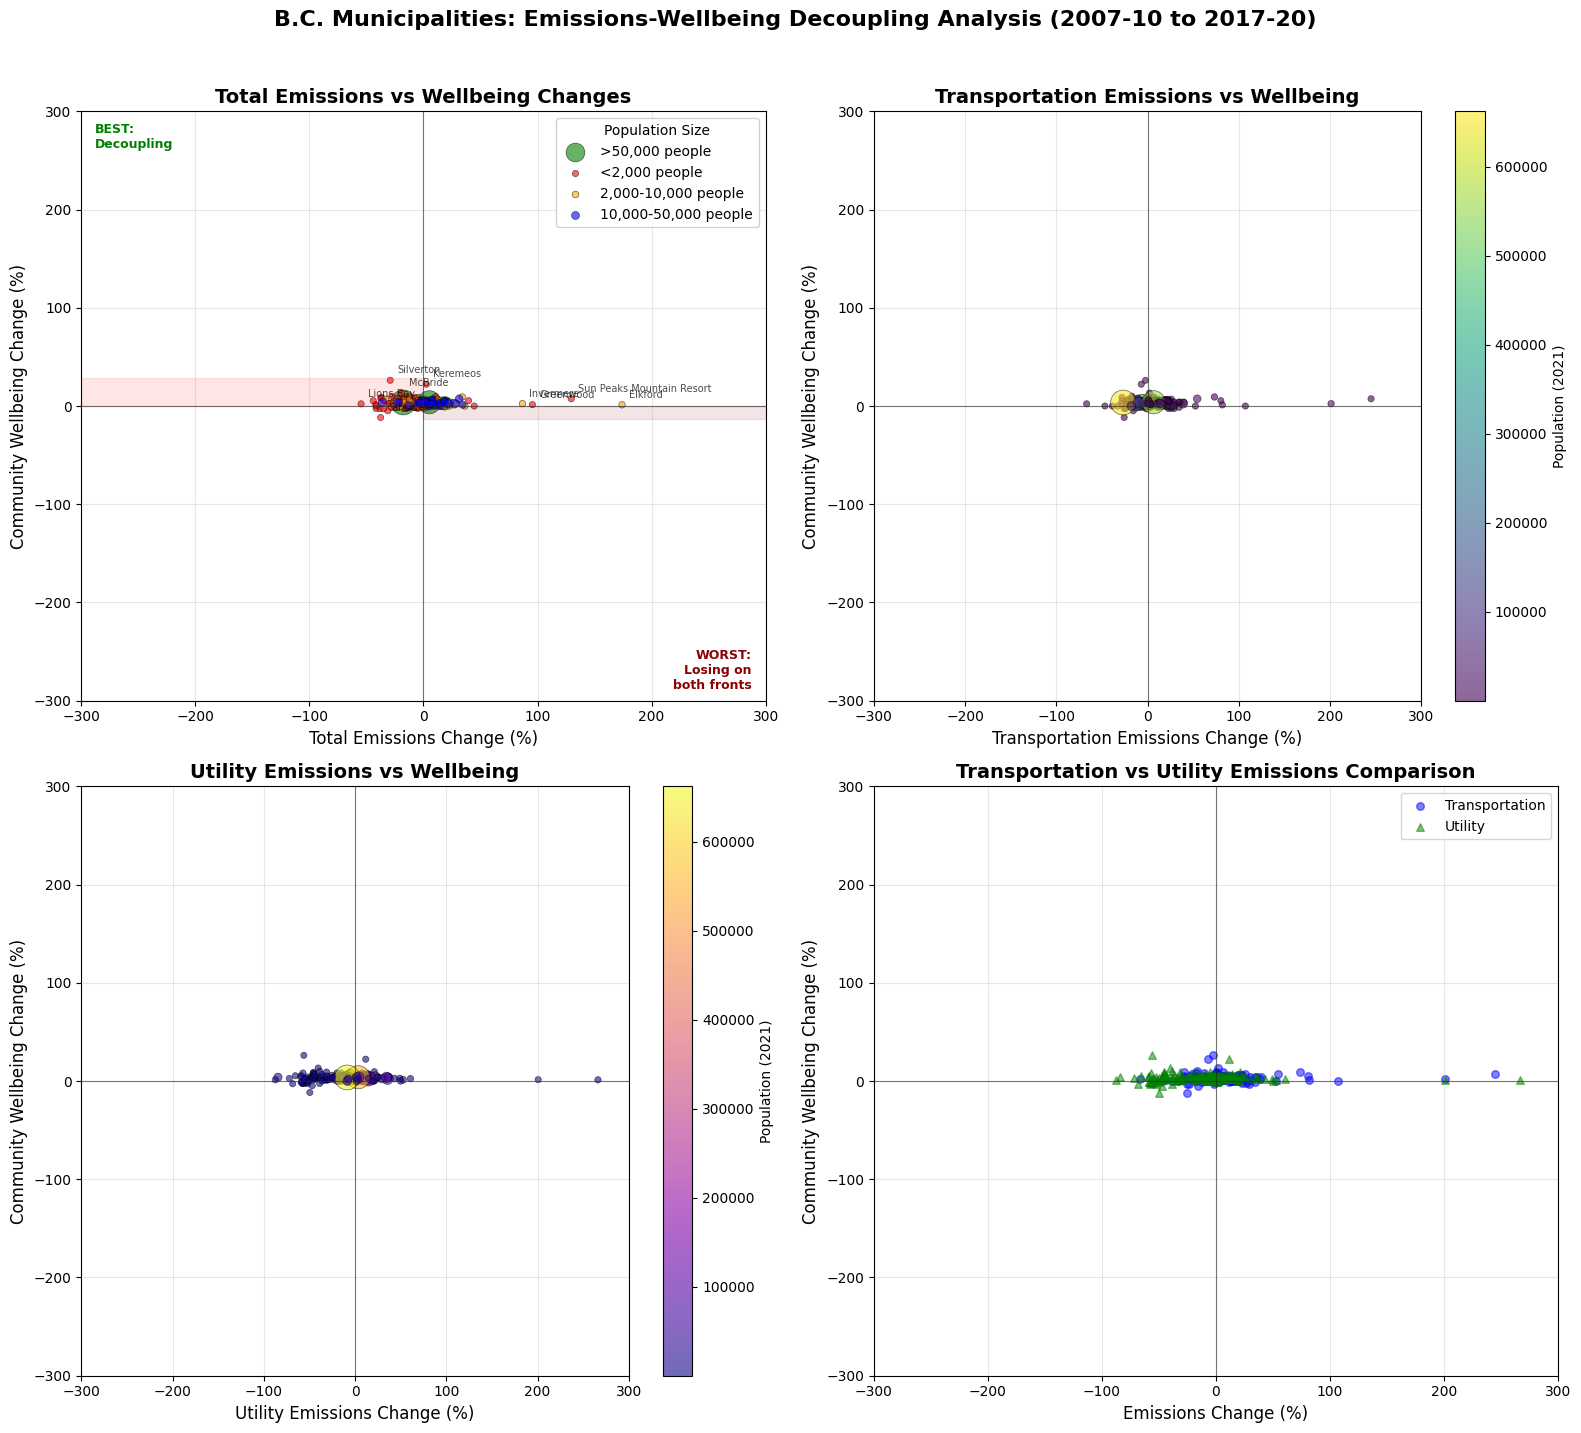


DECOUPLING ANALYSIS SUMMARY

Total municipalities analyzed: 161

Quadrant                            Count Percentage
--------------------------------------------------
Strong Decoupling (↓E, ↑W)             72      44.7%
Growth Coupled (↑E, ↑W)                64      39.8%
Decline Coupled (↓E, ↓W)               13       8.1%
Worst Case (↑E, ↓W)                     0       0.0%

--------------------------------------------------
EMISSIONS CHANGE STATISTICS
--------------------------------------------------

Metric                          Mean     Median    Std Dev
--------------------------------------------------
Total Emissions                 -0.6%       -1.9%       27.4%
Transportation                   9.3%        5.9%       32.4%
Utility                        -10.6%       -7.3%       40.1%
Wellbeing (CWB)                  3.3%        2.7%        3.8%

--------------------------------------------------
CORRELATION ANALYSIS
--------------------------------------------------
Tota

/var/folders/tz/h908n3mn66g0rbqgfkhy5yl40000gn/T/ipykernel_17896/2605731328.py:228: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  strong_decoupling['decoupling_score'] = strong_decoupling['cwb_percent_change'] - strong_decoupling['total_emissions_percent_change']


In [76]:

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Calculate total emissions change (you might want to weight this differently)
# Option 1: Simple average
final_analysis_data['total_emissions_percent_change'] = (
    final_analysis_data['transportation_emissions_percent_change'] + 
    final_analysis_data['utility_emissions_percent_change']
) / 2

# Create population size categories for coloring
final_analysis_data['pop_category'] = pd.cut(
    final_analysis_data['Census Population 2021'],
    bins=[0, 2000, 10000, 50000, float('inf')],
    labels=['<2,000', '2,000-10,000', '10,000-50,000', '>50,000']
)

# Color map for population categories
colors = {'<2,000': 'red', '2,000-10,000': 'orange', '10,000-50,000': 'blue', '>50,000': 'green'}

# Normalize population for point sizes
pop_sizes = (final_analysis_data['Census Population 2021'] / final_analysis_data['Census Population 2021'].max()) * 300 + 20

# ========== PLOT 1: Total Emissions vs CWB ==========
ax1 = axes[0, 0]

for category in final_analysis_data['pop_category'].unique():
    if pd.notna(category):
        mask = final_analysis_data['pop_category'] == category
        ax1.scatter(
            final_analysis_data.loc[mask, 'total_emissions_percent_change'],
            final_analysis_data.loc[mask, 'cwb_percent_change'],
            s=pop_sizes[mask],
            alpha=0.6,
            c=colors[category],
            label=f'{category} people',
            edgecolors='black',
            linewidth=0.5
        )

# Add quadrant lines
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Add shaded quadrants
ax1.axhspan(0, ax1.get_ylim()[1], xmin=0, xmax=0.5, alpha=0.1, color='red')  # top left - best case
ax1.axhspan(ax1.get_ylim()[0], 0, xmin=0.5, xmax=1, alpha=0.1, color='darkred')  # bottom right - worst case

# Label outliers
threshold_emissions = 50  # Adjust based on your data
threshold_wellbeing = 10
for idx, row in final_analysis_data.iterrows():
    if abs(row['total_emissions_percent_change']) > threshold_emissions or abs(row['cwb_percent_change']) > threshold_wellbeing:
        ax1.annotate(
            row['Municipality_Name'], 
            (row['total_emissions_percent_change'], row['cwb_percent_change']),
            fontsize=7, 
            alpha=0.7,
            xytext=(5, 5),
            textcoords='offset points'
        )

ax1.set_xlabel('Total Emissions Change (%)', fontsize=12)
ax1.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax1.set_title('Total Emissions vs Wellbeing Changes', fontsize=14, fontweight='bold')
ax1.legend(title='Population Size', loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-300, 300)
ax1.set_ylim(-300, 300)

# Add quadrant labels
ax1.text(0.02, 0.98, 'BEST:\nDecoupling', transform=ax1.transAxes, fontsize=9, 
         verticalalignment='top', fontweight='bold', color='green')
ax1.text(0.98, 0.02, 'WORST:\nLosing on\nboth fronts', transform=ax1.transAxes, 
         fontsize=9, ha='right', fontweight='bold', color='darkred')

# ========== PLOT 2: Transportation vs CWB ==========
ax2 = axes[0, 1]

scatter2 = ax2.scatter(
    final_analysis_data['transportation_emissions_percent_change'],
    final_analysis_data['cwb_percent_change'],
    s=pop_sizes,
    c=final_analysis_data['Census Population 2021'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax2.set_xlabel('Transportation Emissions Change (%)', fontsize=12)
ax2.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax2.set_title('Transportation Emissions vs Wellbeing', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-300, 300)
ax2.set_ylim(-300, 300)

# Add colorbar for population
cbar2 = plt.colorbar(scatter2, ax=ax2)
cbar2.set_label('Population (2021)', fontsize=10)

# ========== PLOT 3: Utility vs CWB ==========
ax3 = axes[1, 0]

scatter3 = ax3.scatter(
    final_analysis_data['utility_emissions_percent_change'],
    final_analysis_data['cwb_percent_change'],
    s=pop_sizes,
    c=final_analysis_data['Census Population 2021'],
    cmap='plasma',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax3.set_xlabel('Utility Emissions Change (%)', fontsize=12)
ax3.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax3.set_title('Utility Emissions vs Wellbeing', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim(-300, 300)
ax3.set_ylim(-300, 300)

# Add colorbar
cbar3 = plt.colorbar(scatter3, ax=ax3)
cbar3.set_label('Population (2021)', fontsize=10)

# ========== PLOT 4: Comparison Plot ==========
ax4 = axes[1, 1]

# Plot both types on same axes with different markers
ax4.scatter(final_analysis_data['transportation_emissions_percent_change'], 
           final_analysis_data['cwb_percent_change'],
           s=30, alpha=0.5, c='blue', label='Transportation', marker='o')
ax4.scatter(final_analysis_data['utility_emissions_percent_change'], 
           final_analysis_data['cwb_percent_change'],
           s=30, alpha=0.5, c='green', label='Utility', marker='^')

ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

ax4.set_xlabel('Emissions Change (%)', fontsize=12)
ax4.set_ylabel('Community Wellbeing Change (%)', fontsize=12)
ax4.set_title('Transportation vs Utility Emissions Comparison', fontsize=14, fontweight='bold')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(-300, 300)
ax4.set_ylim(-300, 300)

plt.suptitle('B.C. Municipalities: Emissions-Wellbeing Decoupling Analysis (2007-10 to 2017-20)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========== PRINT ANALYSIS ==========
print("\n" + "="*60)
print("DECOUPLING ANALYSIS SUMMARY")
print("="*60)

# Remove NaN values for analysis
clean_data = final_analysis_data.dropna(subset=['total_emissions_percent_change', 'cwb_percent_change'])
print(f"\nTotal municipalities analyzed: {len(clean_data)}")

# Calculate quadrants
strong_decoupling = clean_data[(clean_data['total_emissions_percent_change'] < 0) & 
                               (clean_data['cwb_percent_change'] > 0)]
growth_coupled = clean_data[(clean_data['total_emissions_percent_change'] > 0) & 
                           (clean_data['cwb_percent_change'] > 0)]
decline_coupled = clean_data[(clean_data['total_emissions_percent_change'] < 0) & 
                            (clean_data['cwb_percent_change'] < 0)]
worst_case = clean_data[(clean_data['total_emissions_percent_change'] > 0) & 
                       (clean_data['cwb_percent_change'] < 0)]

print(f"\n{'Quadrant':<30} {'Count':>10} {'Percentage':>10}")
print("-"*50)
print(f"{'Strong Decoupling (↓E, ↑W)':<30} {len(strong_decoupling):>10} {len(strong_decoupling)/len(clean_data)*100:>9.1f}%")
print(f"{'Growth Coupled (↑E, ↑W)':<30} {len(growth_coupled):>10} {len(growth_coupled)/len(clean_data)*100:>9.1f}%")
print(f"{'Decline Coupled (↓E, ↓W)':<30} {len(decline_coupled):>10} {len(decline_coupled)/len(clean_data)*100:>9.1f}%")
print(f"{'Worst Case (↑E, ↓W)':<30} {len(worst_case):>10} {len(worst_case)/len(clean_data)*100:>9.1f}%")

# Statistics by emissions type
print("\n" + "-"*50)
print("EMISSIONS CHANGE STATISTICS")
print("-"*50)
print(f"\n{'Metric':<25} {'Mean':>10} {'Median':>10} {'Std Dev':>10}")
print("-"*50)
print(f"{'Total Emissions':<25} {clean_data['total_emissions_percent_change'].mean():>10.1f}% {clean_data['total_emissions_percent_change'].median():>10.1f}% {clean_data['total_emissions_percent_change'].std():>10.1f}%")
print(f"{'Transportation':<25} {clean_data['transportation_emissions_percent_change'].mean():>10.1f}% {clean_data['transportation_emissions_percent_change'].median():>10.1f}% {clean_data['transportation_emissions_percent_change'].std():>10.1f}%")
print(f"{'Utility':<25} {clean_data['utility_emissions_percent_change'].mean():>10.1f}% {clean_data['utility_emissions_percent_change'].median():>10.1f}% {clean_data['utility_emissions_percent_change'].std():>10.1f}%")
print(f"{'Wellbeing (CWB)':<25} {clean_data['cwb_percent_change'].mean():>10.1f}% {clean_data['cwb_percent_change'].median():>10.1f}% {clean_data['cwb_percent_change'].std():>10.1f}%")

# Correlation analysis
print("\n" + "-"*50)
print("CORRELATION ANALYSIS")
print("-"*50)
corr_total = clean_data['total_emissions_percent_change'].corr(clean_data['cwb_percent_change'])
corr_transport = clean_data['transportation_emissions_percent_change'].corr(clean_data['cwb_percent_change'])
corr_utility = clean_data['utility_emissions_percent_change'].corr(clean_data['cwb_percent_change'])

print(f"Total Emissions vs Wellbeing:         {corr_total:.3f}")
print(f"Transportation Emissions vs Wellbeing: {corr_transport:.3f}")
print(f"Utility Emissions vs Wellbeing:        {corr_utility:.3f}")

# Worst performers detail
if len(worst_case) > 0:
    print("\n" + "-"*50)
    print("MUNICIPALITIES IN WORST CASE QUADRANT")
    print("-"*50)
    worst_sorted = worst_case.sort_values('cwb_percent_change')
    for _, row in worst_sorted.iterrows():
        print(f"\n{row['Municipality_Name']}:")
        print(f"  Population: {row['Census Population 2021']:,.0f}")
        print(f"  Wellbeing Change: {row['cwb_percent_change']:.1f}%")
        print(f"  Total Emissions Change: {row['total_emissions_percent_change']:.1f}%")
        print(f"  (Transport: {row['transportation_emissions_percent_change']:.1f}%, Utility: {row['utility_emissions_percent_change']:.1f}%)")

# Best performers
if len(strong_decoupling) > 0:
    print("\n" + "-"*50)
    print("TOP 5 STRONG DECOUPLING MUNICIPALITIES")
    print("-"*50)
    # Sort by combination of wellbeing increase and emissions decrease
    strong_decoupling['decoupling_score'] = strong_decoupling['cwb_percent_change'] - strong_decoupling['total_emissions_percent_change']
    best_sorted = strong_decoupling.nlargest(5, 'decoupling_score')
    for _, row in best_sorted.iterrows():
        print(f"\n{row['Municipality_Name']}:")
        print(f"  Population: {row['Census Population 2021']:,.0f}")
        print(f"  Wellbeing Change: {row['cwb_percent_change']:.1f}%")
        print(f"  Total Emissions Change: {row['total_emissions_percent_change']:.1f}%")